# Memmingen -- Unabhängige Druck-Validierung mit pandapipes

**Ziel**: Unser Pyomo/Gurobi-MILP berechnet Druck/Pumpen-Physik über eine
**linearisierte** Näherung (konvexe Tangenten-/Sekanten-Hüllkurven, siehe
`docs/paper_2/CALION_Paper2_Implementation_Statement.md` Part H). Das ist
nötig, damit die Physik gleichzeitig mit Dispatch/Investitionsentscheidungen
in EINEM MILP lösbar bleibt: kostet aber etwas an physikalischer Exaktheit.

**pandapipes** ist ein eigenständiger, nicht-linearer hydraulischer Solver
(Newton-Raphson, echte Colebrook-White-Reibung, Reynolds-abhängig): er kann
keine Investitions-/Dispatch-Entscheidungen treffen, aber für EINEN gegebenen
Betriebspunkt (feste Flüsse, feste Erzeugerdrücke) liefert er eine praktisch
"exakte" Referenzlösung.

**Methode dieses Notebooks**: Wir lösen unser MILP für eine echte Woche,
extrahieren die GELÖSTEN Flüsse zu einer bestimmten Stunde, füttern diese
EXAKT GLEICHEN Flüsse in ein äquivalentes pandapipes-Netz (gleiche Topologie,
echte Rohrlängen/-durchmesser aus `Memmingen_pressure_stations.yaml`), lösen
pandapipes' echte nicht-lineare Gleichungen, und vergleichen Knoten für
Knoten. 

## Zusammenfassung: Wie wir Druck/Pumpen-Physik berechnen -- und wie gut das ist

Diese Zelle ist die Kurzfassung für alle, die nicht jede Code-Zelle lesen
wollen. Details und Belege stehen in den Zellen darunter.

### 1. Die physikalische Grundlage

Der Druckverlust in einem Rohr folgt Darcy-Weisbach:

```
Δp = f · (L / D) · (ρ / 2) · v²         (v = Fließgeschwindigkeit, quadratisch im Durchfluss)
```

`f` (Reibungsfaktor) hängt eigentlich von der Reynolds-Zahl und der relativen
Rohrrauheit ab (Colebrook-White-Gleichung, nicht-linear). Die Pumpenleistung
folgt aus dem Förderhöhen-Wirkungsgrad-Zusammenhang und ist **kubisch** im
Durchfluss (Δp · V̇ / η).

### 2. Warum wir NICHT direkt Darcy-Weisbach lösen

Unser Modell muss Druck/Pumpen-Physik GLEICHZEITIG mit
Investitions-/Dispatch-Entscheidungen (Kapazitäten, An/Aus-Schaltungen,
Speicher-Fahrweise) in EINEM gemischt-ganzzahligen linearen Programm (MILP)
lösen. Eine echte quadratische/kubische Gleichung würde das Problem
nicht-linear (NLP) oder erheblich schwerer machen (Binärvariablen für jede
Kombination). Deshalb linearisieren wir:

- **Konvexe Tangenten-Hüllkurve, ohne Binärvariablen**: An mehreren
  Stützpunkten des Durchflusses (33/67/100% der Rohr-Auslegungskapazität,
  siehe `pipe_pair.py`) werden Tangenten an die echte quadratische
  Δp(ṁ)-Kurve gelegt und als lineare UNTERGRENZEN eingetragen. Weil `Δp`
  (über die Pumpenkosten) im Zielfunktionswert mit einem POSITIVEN
  Koeffizienten steht, hat der Solver einen echten Anreiz, `Δp` so klein wie
  möglich zu halten und landet dadurch automatisch auf der straffsten
  bindenden Tangente, ohne dass man ihm mit Binärvariablen vorschreiben
  muss, welches Segment gilt. Dieselbe Idee gilt für `P_pump(ṁ)` (kubisch).
- **Verdichtung bei niedrigem Durchfluss** (`add_low_flow_tangents()`,
  Cell 2): die 3 Standard-Tangenten allein werden unterhalb von ca. 22% der
  Auslegungskapazität nicht-bindend (die Tangente an einem hohen
  Referenzpunkt liegt bei kleinem `ṁ` unter Null) -- typisch für die
  meisten echten Betriebsstunden. Ohne zusätzliche Tangenten bei 2/5/8/12/
  18/25% der Kapazität könnte `Δp`/`P_pump` an der Variablen-Untergrenze (0)
  hängen bleiben, statt den echten (kleinen) Wert zu zeigen.
- **Zuleitungs-Verluste** (`lateral_dp_extra`, kleine DN32-Rohre von der
  Trasse zur Übergabestation): eigene, separate PWL mit gewichteter
  Stützpunkt-Kombination (konvexe Kombination, siehe Pumpstudie-Notebook).
- **Erzeuger-/Fortpflanzungs-Druck**: der Haupterzeuger (`j_9`) hat einen
  FEST vorgegebenen `setpoint_bar`. Stromabwärts wird der Druck über
  Ungleichungen fortgepflanzt (`P_to <= P_from - Δp`, mit etwas Spielraum
  statt strikter Gleichheit, aus numerischen Gründen). Ein optionaler
  `pressure_regularization`-Term (kleiner Zielfunktions-Koeffizient) drängt
  Verbraucherknoten zum straffsten (physikalisch korrekten) Wert, statt sie
  beliebig im Spielraum sitzen zu lassen.

### 3. Wie wir das gegen pandapipes prüfen

Wir lösen unser MILP für eine echte Woche, extrahieren die GELÖSTEN Flüsse
zu einer festen Stunde, und füttern EXAKT DIESE Flüsse in ein äquivalentes
pandapipes-Netz (gleiche Topologie, echte Rohrlängen/-durchmesser).
pandapipes löst dann die ECHTEN nicht-linearen Gleichungen (Newton-Raphson,
Colebrook-White) für genau diesen einen Betriebspunkt. 

### 4. Ergebnis in einem Satz

Für die große Mehrheit des Netzes (Trassenrohre, 9 von 15 Knoten) stimmt
unsere Linearisierung mit der echten nicht-linearen Lösung sehr gut. 

## Detaillierte Methodik: Wie jede Druck-/Pumpengröße berechnet wird

Diese Sektion geht deutlich tiefer als die Kurzfassung oben -- mit den
tatsächlichen Formeln, den exakten Constraint-Definitionen aus dem Code,
und den Grenzen jeder Vereinfachung. Referenzierter Code:
`calion/models/blocks/pipe_pair.py`, `calion/models/blocks/thermal_node.py`,
`calion/models/network_manager.py`.

### 1. Physikalische Grundgleichung (Darcy-Weisbach)

Reibungsdruckverlust in einem Rohr:

```
Δp = f · (L/D) · (ρ/2) · v²
```

Mit `v = ṇ/(ρ·A)` (Massenstrom durch Querschnittsfläche) wird das zu einer
reinen Funktion des Massenstroms:

```
Δp(ṇ) = k_flow · ṇ²,      k_flow = f · L / (2 · ρ · D · A²)
```

`f` (Reibungsfaktor) hängt über die Colebrook-White-Gleichung eigentlich
von der Reynolds-Zahl und der relativen Rohrrauheit ab (nicht-linear) --
wir nehmen ihn KONSTANT an (Standard `f=0.02`). Teil 1 validiert diese
Annahme unabhängig gegen pandapipes: sehr gut für Trassenrohre (echter Wert
0.0166-0.0221), ~30-45% zu niedrig für die kleinen DN32-Zuleitungen (echter
Wert 0.027-0.030).

Pumpleistung (mechanisch, mit Wirkungsgrad η):

```
P_pump(ṇ) = Δp · V̇ / η = Δp · ṇ / (ρ·η) = k_flow · ṇ³ / (ρ·η) = c_pump · ṇ³
```

-- **kubisch** im Massenstrom, nicht quadratisch wie Δp selbst.

### 2. Trassen-Linearisierung: konvexe Tangenten-Hüllkurve

`Δp(ṇ)` und `P_pump(ṇ)` sind konvexe Funktionen, UND beide stehen im
Zielfunktionswert mit einem POSITIVEN Kostenkoeffizienten (die Pumpenkosten
sollen minimiert werden). Für eine solche Konstellation reicht eine Menge
linearer UNTERGRENZEN (Tangenten an mehreren Stützpunkten `ṇ_i`), um die
exakte konvexe Funktion am Optimum zu reproduzieren -- **ohne
Binärvariablen oder SOS2**:

```
Tangente an ṇ_i:   Δp(ṇ)     ≥ 2·k_flow·ṇ_i·ṇ  -   k_flow·ṇ_i²
                    P_pump(ṇ) ≥ 3·c_pump·ṇ_i²·ṇ - 2·c_pump·ṇ_i³
```

(jeweils die Tangente der Parabel/Kubik am Punkt `ṇ_i` -- Standard-Technik
für konvexe Piecewise-Linearisierung ohne Ganzzahligkeit). `pipe_pair.py`
setzt 3 Standard-Stützpunkte bei 33/67/100% der Rohr-Auslegungskapazität.

**Warum das (meistens) exakt ist**: der Solver hat einen echten Anreiz,
`Δp`/`P_pump` so klein wie möglich zu halten (Minimierungsrichtung + echte
Kosten) -- er landet deshalb automatisch auf der straffsten bindenden
Tangente, was GENAU dem wahren Funktionswert entspricht, keine Näherung.
**Wo das bricht**: bei sehr niedrigem Durchfluss (unter ca. 22% der
Auslegungskapazität) liegen alle 3 Standard-Tangenten unterhalb von Null
und werden nicht-bindend -- `add_low_flow_tangents()` (in diesem Notebook
verwendet) fügt deshalb 6 weitere Stützpunkte bei 2/5/8/12/18/25% hinzu.
**Trotzdem nicht vollständig geschlossen**: Teil "Nachtrag" unten zeigt,
dass die Pumpenleistung übers Jahr nur schwach (r=0.41) mit dem echten
Fluss korreliert -- diese Verdichtung reicht nicht in jedem Fall.


### 3. Zuleitungsverlust: gewichtete Stützpunkt-Kombination

Für die kleinen DN32-Zuleitungsrohre (Trasse → Übergabestation) wird
dieselbe konvexe `Δp(ṇ)`-Funktion NICHT über Tangenten, sondern über eine
explizite konvexe Kombination von (Stützpunkt, Funktionswert)-Paaren
dargestellt (`thermal_node.py`):

```
lateral_dp_extra = Σ_k λ_k · Δp(ṇ_k),   mit   ṇ = Σ_k λ_k · ṇ_k,
                    Σ_k λ_k = 1,   λ_k ≥ 0
```

`ṇ` hier ist der Durchfluss PRO STATION (`m_dot_demand / n_transfer_stations`),
nicht der Knoten-Gesamtfluss jede reale Zuleitung trägt nur den Anteil
EINER Übergabestation. Für eine konvexe Funktion, die nur in
Minimierungsrichtung gebraucht wird, ist auch das exakt darstellbar ohne
Binärvariablen.

### 4. Druckfortpflanzung im Netz (`network_manager.py::_link_pressure_propagation`)

- **Haupterzeuger** (`j_9`): `P_supply` FEST auf den Sollwert (6.38 bar --
  reales Δp-c-Kurvenmaximum der installierten Wilo IL-E 65/11-64 BF Pumpe).
- **Sekundärer Erzeuger** (`j_12`): `P_supply` FREI, per
  topologie-skaliertem Tie-Break auf seinen eigenen, echten Fußpunkt
  (6.38 bar) gezogen (Fazit Kategorie B.5).
- **Alle anderen (propagierten) Knoten**: Ungleichung statt Gleichheit
  (numerische Gründe, PWL-Kompatibilität):
  ```
  P_supply[Knoten]   ≤ P_supply[Vorgänger] - Δp_Trasse(ṇ)
  P_return[Vorgänger] ≤ P_return[Knoten]   - Δp_Trasse_Rücklauf(ṇ)
  ```
- **Regularisierung** (`pressure_regularization`, opt-in, hier AN,
  `epsilon=1e-4`): ein kleiner Zielfunktions-Term (`-epsilon · P_supply[Knoten]`)
  drängt jeden propagierten Knoten dazu, den Spielraum der obigen
  Ungleichung voll auszunutzen (`P_supply` so HOCH wie erlaubt), statt
  beliebig darunter zu liegen -- ohne das wäre `P_supply` an jedem nicht
  direkt bindenden Knoten ein Solver-Artefakt (bekanntes Beispiel: `j_12`
  und alles stromabwärts, wo dieser Mechanismus bewusst NICHT greift).
- **`P_return` wird jetzt ebenfalls regularisiert** (Fazit Kategorie B.8):
  ein Push-up-Term nutzt Abschnitt 5(b)s Differenzdruck-Constraint als
  Anker, ausgenommen Erzeuger und ihre kompletten Teilbäume (deren
  `P_supply` separat nach UNTEN geschoben wird -- ein Push-up dort würde
  genau dagegen arbeiten). Teil 5 unten zeigt dadurch für die 6 echten
  Übergabestationen jetzt engen, verifizierten Slack statt eines
  Artefakts.

### 5. Minimaldruck an Verbraucherknoten -- ZWEI SEPARATE, UNVERKNÜPFTE Constraints

**(a) Absoluter Fußpunkt** (`network_manager.py`):
```
P_supply[Knoten] ≥ min_required_bar     (hier: 2.0 bar, für alle Verbraucher gleich)
```
Grundlage für die Margin-Analyse in Teil 3.

**(b) Differenzdruck an der Übergabestation** (`thermal_node.py::_station_dp_rule`):
```
P_supply[Knoten] - P_return[Knoten] ≥ delta_p_min_consumer_bar + lateral_dp_extra[Knoten]
```
mit `delta_p_min_consumer_bar = 0.6 bar` (60 kPa) -- **ein echter
Spezifikationswert**, nicht angenommen: `Netzkomponenten_Spezifikationen.xlsx`,
Blatt "Uebergabestation", listet sowohl "min Differenzdruck Waermenetz" als
auch "Druckverluste" mit 0.6 bar. Das ist die eigentliche physikalische
Anforderung des Regelventils an der Station. Teil 5 unten prüft das direkt.

**Wichtig**: `min_required_bar` (2.0 bar) ist NICHT als "0.6 + typischer
Zuleitungsverlust" hergeleitet -- es ist ein unabhängig gewählter,
konstanter Fußpunkt, gleich für alle Knoten trotz sehr unterschiedlicher
Zuleitungsverluste (0.02 bis 0.6+ bar je Knoten, siehe Teil 3). Die beiden
Constraints (a) und (b) können also unterschiedlich knapp sein -- (a) ist
in Teil 3/4 gezeigt, (b) erst in Teil 5 unten.

### 6. Pumpenleistungs-Kosten (`network_manager.py::_link_pump_head`)

Jeder Erzeuger (`j_9`, `j_12`) übernimmt die Pumpenleistung für jedes Rohr
auf seinem eigenen Ast (Multi-Source-BFS vom Erzeuger, endet an der
nächsten Erzeuger-Grenze) PLUS die Stations-/Zuleitungspumparbeit:
```
producer_P_pump_total = Σ_Rohre P_pump(Rohr)
                       + Σ_Knoten [ delta_p_min_consumer_bar · m_dot_demand
                                     + P_pump_lateral(Knoten) ]
```
Diese Summe fließt als ECHTE Stromlast in den Strombus (`el_in`) --
keine reine Kosten-Buchhaltung, sondern Teil der tatsächlichen
Dispatch-Physik im MILP.

### Cell 1 — Setup: Imports (inkl. pandapipes)

In [1]:
# =============================================================================
# Cell 1 — Setup
# =============================================================================
import sys
import time
import math as _math
from pathlib import Path

_ROOT = Path(r"c:\Users\LKR\Documents\GitHub\Energy_Framwork\Planing-Framework-for-Heat")
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    # Forces Jupyter's own inline renderer regardless of matplotlib's system
    # default backend (this host defaults to TkAgg, a GUI-popup backend that
    # silently fails to render on a headless/remote box -- this is why plots
    # were not showing). get_ipython() only exists inside a real IPython/
    # Jupyter kernel, so this is a no-op (and harmless) when this cell's
    # source is exec()'d as plain Python by the worker/verification scripts.
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import pyomo.environ as pyo
import pandapipes as pp

from scripts.paper_2.scenario_runner import (
    _load_yaml, _dump_yaml_tmp, _apply_spatial_temperature_offsets,
    _inject_cop_series, _load_outdoor_temps, _load_hp_source_temps,
)
from calion.run.workflow import _build_workflow_inputs
from calion.utils.heizkurve import compute_heizkurve
from calion.utils.cop_wrapper import precompute_cop
from calion.models.system_builder import build_model

# BUGFIX (2026-08-06): several calion.io.* modules unconditionally call
# matplotlib.use('Agg') at import time (their own headless batch-export use
# case) -- calion.run.workflow imports one of these transitively, silently
# undoing the %matplotlib inline magic set above. Without this, EVERY
# plt.show() in this notebook renders to a non-interactive canvas and shows
# nothing (UserWarning: "FigureCanvasAgg is non-interactive"). Re-assert
# inline mode now that all calion imports (and their side effects) are done.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

CONFIG_PATH = _ROOT / "configs" / "pressure" / "Memmingen_pressure_stations.yaml"
print("Setup OK. pandapipes version:", pp.__version__)
print("matplotlib backend:", plt.get_backend())


Setup OK. pandapipes version: 0.14.0
matplotlib backend: inline


### Cell 2 —  MILP  (Winterwoche)

In [2]:
# =============================================================================
# Cell 2 — add_low_flow_tangents() + build_and_solve() helpers
# =============================================================================
def add_low_flow_tangents(model, network_manager, extra_fracs=(0.02, 0.05, 0.08, 0.12, 0.18, 0.25)):
    density_water = 1000.0
    f_friction = 0.02
    max_velocity = float(network_manager._net_cfg.get('max_velocity_m_s', 2.5))
    eta_pump = float(network_manager._net_cfg.get('pump_efficiency', 0.70))
    n_added = 0
    for pipe_id, pipe_cfg in network_manager.pipes.items():
        prefix = pipe_id.upper().replace('-', '_')
        m_dot_var = getattr(model, f'{prefix}_m_dot', None)
        delta_p_supply = getattr(model, f'{prefix}_delta_p_supply', None)
        P_pump_var = getattr(model, f'{prefix}_P_pump', None)
        if m_dot_var is None or delta_p_supply is None:
            continue
        length_m = float(pipe_cfg.get('length_m', 0) or 0)
        diameter_mm = float(pipe_cfg.get('diameter_mm', 0) or 0)
        if length_m <= 0 or diameter_mm <= 0:
            continue
        d_inner_m = diameter_mm / 1000.0 * 0.94
        area_m2 = _math.pi * (d_inner_m / 2.0) ** 2
        effective_max_flow = area_m2 * max_velocity * density_water
        k_pressure = f_friction * (length_m / d_inner_m) * (density_water / 2.0) / 1e5
        k_flow = k_pressure / ((density_water * area_m2) ** 2)
        c_pump = 2.0 * k_flow * 1e5 / (density_water * eta_pump * 1e6)
        for frac in extra_fracs:
            mi = frac * effective_max_flow
            if mi <= 0:
                continue
            setattr(model, f'{prefix}_dp_lowflow_{int(frac*1000)}',
                    pyo.Constraint(model.t, rule=(
                        lambda m, t, _mdv=m_dot_var, _dp=delta_p_supply, _mi=mi, _kf=k_flow:
                        _dp[t] >= 2.0 * _kf * _mi * _mdv[t] - _kf * _mi ** 2
                    )))
            n_added += 1
            if P_pump_var is not None:
                setattr(model, f'{prefix}_pp_lowflow_{int(frac*1000)}',
                        pyo.Constraint(model.t, rule=(
                            lambda m, t, _mdv=m_dot_var, _pp=P_pump_var, _mi=mi, _c=c_pump:
                            _pp[t] >= 3.0 * _c * _mi ** 2 * _mdv[t] - 2.0 * _c * _mi ** 3
                        )))
                n_added += 1
    return n_added


def build_and_solve(horizon_start, horizon_end, label, time_limit_s=90, mip_gap=0.03, n_threads=None):
    cfg = _load_yaml(CONFIG_PATH)
    cfg["scenario"]["horizon"] = {"start": horizon_start, "end": horizon_end}
    tmp1 = _dump_yaml_tmp(cfg)
    inputs0 = _build_workflow_inputs([str(tmp1)], overrides=None)
    table = inputs0.table
    try:
        tmp1.unlink()
    except OSError:
        pass
    hc = cfg["network"]["heating_curve"]
    T_aus = _load_outdoor_temps(table, cfg)
    T_VL_ts = compute_heizkurve(k=hc["k"], T_VL_min_c=hc["T_supply_min_c"], T_VL_max_c=hc["T_supply_max_c"], T_aus_ts=T_aus)
    return_temp_c = float(cfg.get("network", {}).get("return_temp_c", 60.0))
    min_delta_T = float(cfg.get("network", {}).get("min_supply_delta_T_k", 10.0))
    T_VL_min_effective = max(float(hc["T_supply_min_c"]), return_temp_c + min_delta_T)
    T_VL_ts = np.maximum(T_VL_ts, T_VL_min_effective)
    cfg["network"]["heating_curve"]["T_supply_min_c"] = T_VL_min_effective
    cfg.setdefault("heat_pumps", {}).setdefault("cop", {})
    cfg["heat_pumps"]["cop"]["supply_temp_min_c"] = T_VL_min_effective
    cfg["heat_pumps"]["cop"]["supply_temp_max_c"] = hc["T_supply_max_c"]
    delta_T_scenario_k = round(T_VL_min_effective - return_temp_c, 2)
    for _ak, _acfg in cfg.get("assets", {}).items():
        if _acfg.get("type") == "geometric_storage":
            _acfg["delta_T_scenario_k"] = delta_T_scenario_k
    T_source_ts = _load_hp_source_temps(cfg, table)
    cop_ts = precompute_cop(T_VL_ts=T_VL_ts, T_source_ts=T_source_ts, table=table, cfg=cfg, hp_type="standard")
    _inject_cop_series(cfg, cop_ts)
    _apply_spatial_temperature_offsets(cfg, T_VL_ts, f"MM-PP-{label}")
    tmp = _dump_yaml_tmp(cfg)
    inputs = _build_workflow_inputs([str(tmp)], overrides=None)
    try:
        tmp.unlink()
    except OSError:
        pass
    model = build_model(inputs.table, inputs.cfg, dt_h=inputs.dt_h)
    n_tangents = add_low_flow_tangents(model, model._network_manager)
    print(f"[{label}] build OK, added {n_tangents} low-flow tangent constraints")
    solver_options = dict(inputs.cfg.get("run", {}).get("solver_options", {}))
    solver_options["TimeLimit"] = time_limit_s
    solver_options["MIPGap"] = mip_gap
    if n_threads is not None:
        solver_options["Threads"] = n_threads
    opt = pyo.SolverFactory(inputs.solver_name)
    for k, v in solver_options.items():
        opt.options[k] = v
    res = opt.solve(model, tee=False, warmstart=False, load_solutions=False)
    n_sol = len(res.solution) if hasattr(res, "solution") else 0
    print(f"[{label}] termination={res.solver.termination_condition}, n_sol={n_sol}")
    if n_sol == 0:
        raise RuntimeError(f"[{label}] no incumbent")
    model.solutions.load_from(res)
    return model, cfg, inputs


model, cfg, inputs = build_and_solve("2025-12-29 00:00", "2026-01-04 23:00", "WINTER", time_limit_s=90)


[2026-08-06 14:13:48] calion.io.loader - INFO - [LOAD] Outdoor temperature found: column 'outdoor_temp_C'
[2026-08-06 14:14:02] calion.io.loader - WARNING - [LOAD] Clipping 2 negative heat demand value(s) to zero in column 'waermebedarf_MWth'
[2026-08-06 14:14:08] calion.io.loader - INFO - [LOAD] Import_Data_Memmingen_epronet_cleaned.xlsx -> 10824 steps from 2025-01-01 00:00:00 to 2026-03-27 23:00:00
[2026-08-06 14:14:11] calion.run.utilities.timeseries_utils - INFO - [SCENARIO] Zeitraum 2025-12-29 00:00:00 → 2026-01-04 23:00:00 (168 Schritte)
[2026-08-06 14:14:11] scripts.paper_2.scenario_runner - INFO - [MM-PP-WINTER] Spatial temperature drop applied to 14 node(s); max cumulative drop from plant = 0.98 K (T_supply Param, no McCormick)
[2026-08-06 14:16:32] calion.io.loader - INFO - [LOAD] Outdoor temperature found: column 'outdoor_temp_C'
[2026-08-06 14:16:48] calion.io.loader - WARNING - [LOAD] Clipping 2 negative heat demand value(s) to zero in column 'waermebedarf_MWth'
[2026-08-0

### Cell 3 — Zwei Betriebspunkte wählen: Spitzenlast + mittlere Last

Damit der Vergleich nicht nur an einem einzigen (evtl. untypischen) Punkt
gilt, prüfen wir sowohl die höchste als auch eine mittlere Gesamtlast-Stunde
innerhalb derselben Woche.

Peak-demand hour:   index=108, t=109, total_flow=28.93 kg/s
Median-demand hour: index=70, t=71, total_flow=22.43 kg/s


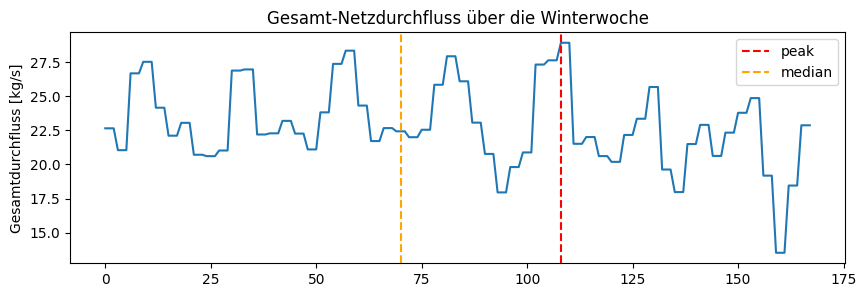

In [3]:
# =============================================================================
# Cell 3 — Pick peak-demand and median-demand hours
# =============================================================================
ts = list(model.t)
PRIMARY = cfg["network"]["primary_producer"]

total_flow_per_t = []
for t in ts:
    total = 0.0
    for nid in cfg["network"]["nodes"]:
        prefix = nid.upper().replace('-', '_')
        m_dot = getattr(model, f"{prefix}_m_dot_demand", None)
        if m_dot is not None:
            total += pyo.value(m_dot[t])
    total_flow_per_t.append(total)

peak_idx = int(np.argmax(total_flow_per_t))
peak_t = ts[peak_idx]
median_idx = int(np.argsort(total_flow_per_t)[len(total_flow_per_t) // 2])
median_t = ts[median_idx]

print(f"Peak-demand hour:   index={peak_idx}, t={peak_t}, total_flow={total_flow_per_t[peak_idx]:.2f} kg/s")
print(f"Median-demand hour: index={median_idx}, t={median_t}, total_flow={total_flow_per_t[median_idx]:.2f} kg/s")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(total_flow_per_t)
ax.axvline(peak_idx, color="red", ls="--", label="peak")
ax.axvline(median_idx, color="orange", ls="--", label="median")
ax.set_ylabel("Gesamtdurchfluss [kg/s]")
ax.set_title("Gesamt-Netzdurchfluss über die Winterwoche")
ax.legend()
plt.show()


### Cell 4 — Gelöste Daten extrahieren

Für jeden Knoten: `pressure_supply`, `pressure_return`, `m_dot_demand`
(Verbrauch), `m_dot_gen` (**lokale Erzeugung** -- siehe Cell 8, warum das
entscheidend ist), `lateral_dp_extra` (falls die reale Zuleitungs-Verlust-
Funktion für diesen Knoten aktiv ist). Für jedes Rohr: `m_dot`,
`delta_p_supply`.

In [4]:
# =============================================================================
# Cell 4 — extract_hour(): pull everything we need from the solved model
# =============================================================================
def extract_hour(model, cfg, t):
    data = {"nodes": {}, "pipes": {}}
    for nid in cfg["network"]["nodes"]:
        prefix = nid.upper().replace('-', '_')
        p_sup = getattr(model, f"{prefix}_pressure_supply", None)
        p_ret = getattr(model, f"{prefix}_pressure_return", None)
        m_dot_demand = getattr(model, f"{prefix}_m_dot_demand", None)
        lat_dp = getattr(model, f"{prefix}_lateral_dp_extra", None)
        # Local generation (heat pump / e-boiler at a secondary 'mixed'
        # producer like j_12) injects ADDITIONAL mass flow right at that
        # node -- constraint_builder.py's shared m_dot_gen Var/Expression.
        m_dot_gen = getattr(model, f"{prefix}_m_dot_gen", None)
        data["nodes"][nid] = {
            "p_supply_bar": pyo.value(p_sup[t]) if p_sup is not None else None,
            "p_return_bar": pyo.value(p_ret[t]) if p_ret is not None else None,
            "m_dot_demand_kg_s": pyo.value(m_dot_demand[t]) if m_dot_demand is not None else 0.0,
            "lateral_dp_extra_bar": pyo.value(lat_dp[t]) if lat_dp is not None else 0.0,
            "m_dot_gen_kg_s": pyo.value(m_dot_gen[t]) if m_dot_gen is not None else 0.0,
        }
    for pid, pcfg in cfg["network"]["pipes"].items():
        pprefix = pid.upper().replace('-', '_')
        m_dot = getattr(model, f"{pprefix}_m_dot", None)
        dp_sup = getattr(model, f"{pprefix}_delta_p_supply", None)
        data["pipes"][pid] = {
            "from": pcfg["from"], "to": pcfg["to"],
            "length_m": pcfg["length_m"], "diameter_mm": pcfg["diameter_mm"],
            "m_dot_kg_s": pyo.value(m_dot[t]) if m_dot is not None else None,
            "delta_p_supply_bar": pyo.value(dp_sup[t]) if dp_sup is not None else None,
        }
    return data


peak_data = extract_hour(model, cfg, peak_t)
median_data = extract_hour(model, cfg, median_t)
print("Extracted peak-hour and median-hour data for", len(peak_data["nodes"]), "nodes,",
      len(peak_data["pipes"]), "pipes.")


Extracted peak-hour and median-hour data for 15 nodes, 14 pipes.


### Cell 5 — Prüfung 1: Massenbilanz VOR dem Bau des pandapipes-Netzes

Bevor wir überhaupt pandapipes anfassen: stimmt die extrahierte Bilanz
`Σ Verbrauch = Σ lokale Erzeugung + Netto-Bezug vom Erzeuger` in UNSEREM
eigenen Modell? Das ist keine pandapipes-Prüfung, sondern eine Kontrolle,
dass wir die richtigen Zahlen extrahiert haben, bevor wir sie weiterreichen.

In [5]:
# =============================================================================
# Cell 5 — Sanity check: our OWN extracted mass balance closes
# =============================================================================
for label, data in [("PEAK", peak_data), ("MEDIAN", median_data)]:
    total_demand = sum(d["m_dot_demand_kg_s"] for d in data["nodes"].values())
    total_gen = sum(d["m_dot_gen_kg_s"] for d in data["nodes"].values())
    net_from_plant = total_demand - total_gen
    print(f"[{label}] total demand={total_demand:.3f} kg/s, total local generation={total_gen:.3f} kg/s, "
          f"net from plant (expected)={net_from_plant:.3f} kg/s")
    assert total_demand >= 0 and total_gen >= 0, "negative flow -- extraction bug"
print("OK -- both hours have a physically sane (non-negative) demand/generation split.")


[PEAK] total demand=28.926 kg/s, total local generation=2.718 kg/s, net from plant (expected)=26.208 kg/s
[MEDIAN] total demand=22.431 kg/s, total local generation=0.000 kg/s, net from plant (expected)=22.431 kg/s
OK -- both hours have a physically sane (non-negative) demand/generation split.


### Cell 6 — pandapipes-Netz aufbauen: Topologie

Direkte Entsprechung:
- **Junction** = unser Knoten (gleiche 15 Knoten)
- **Pipe** (`create_pipe_from_parameters`) = unser Rohr, mit den ECHTEN
  `length_m`/`diameter_mm` aus der YAML (gleicher 0.94-Wandstärkefaktor wie
  in unserem eigenen Modell, damit der Innendurchmesser identisch ist)
- **ext_grid** = unser `primary_producer` (`j_9`), fixiert auf den gleichen
  `setpoint_bar` (4.8 bar)
- **sink** = `m_dot_demand` an jedem Verbraucherknoten (EXAKT der von
  unserem MILP gelöste Wert -- nicht neu berechnet)

`k_mm=0.1` (Rohrrauheit)

In [6]:
# =============================================================================
# Cell 6 — build_pandapipes_net(): topology only (generation source comes
# in Cell 8, after we show why it's needed)
# =============================================================================
def build_pandapipes_net(cfg, hour_data, t_supply_k=353.15, include_generation_sources=True):
    net = pp.create_empty_network(fluid="water")
    junction_of = {}
    for nid in cfg["network"]["nodes"]:
        junction_of[nid] = pp.create_junction(net, pn_bar=25, tfluid_k=t_supply_k, name=nid)

    primary = cfg["network"]["primary_producer"]
    p_setpoint = cfg["network"]["nodes"][primary]["pressure"]["setpoint_bar"]
    pp.create_ext_grid(net, junction=junction_of[primary], p_bar=p_setpoint, t_k=t_supply_k, name="plant")

    for pid, pcfg in cfg["network"]["pipes"].items():
        pp.create_pipe_from_parameters(
            net, from_junction=junction_of[pcfg["from"]], to_junction=junction_of[pcfg["to"]],
            length_km=pcfg["length_m"] / 1000.0,
            inner_diameter_mm=pcfg["diameter_mm"] * 0.94,
            k_mm=0.1, name=pid,
        )

    n_sinks = 0
    for nid, ndata in hour_data["nodes"].items():
        m = ndata["m_dot_demand_kg_s"]
        if m and m > 1e-9:
            pp.create_sink(net, junction=junction_of[nid], mdot_kg_per_s=m, name=f"sink_{nid}")
            n_sinks += 1

    n_sources = 0
    if include_generation_sources:
        for nid, ndata in hour_data["nodes"].items():
            m_gen = ndata.get("m_dot_gen_kg_s", 0.0)
            if m_gen and m_gen > 1e-9:
                pp.create_source(net, junction=junction_of[nid], mdot_kg_per_s=m_gen, name=f"source_{nid}")
                n_sources += 1

    print(f"Built pandapipes net: {len(junction_of)} junctions, {len(cfg['network']['pipes'])} pipes, "
          f"{n_sinks} sinks, {n_sources} local-generation source(s), ext_grid at {primary} = {p_setpoint} bar")
    return net, junction_of


### Cell 7 — Erster Versuch: OHNE lokale Erzeugung als Quelle

`j_12` hat eine eigene Wärmepumpe + E-Kessel (`hp_main`, `eboiler_main`) --
das bedeutet, ein TEIL des Massenstroms, der stromabwärts von `j_12`
gebraucht wird, wird NICHT über die Zuleitung `j11_to_j12` herangeführt,
sondern LOKAL bei `j_12` selbst ins Netz eingespeist (dieselbe Physik wie
`constraint_builder.py`s `m_dot_gen`-Korrektur -- siehe dortige Kommentare).
Lassen wir das zunächst absichtlich weg, um zu zeigen, was passiert, wenn man
es vergisst (genau dieser Fehler ist beim Bauen dieses Notebooks passiert).

In [7]:
# =============================================================================
# Cell 7 — Deliberately WRONG first attempt: no generation source at j_12
# =============================================================================
net_wrong, junction_of = build_pandapipes_net(cfg, peak_data, include_generation_sources=False)
pp.pipeflow(net_wrong, mode="hydraulics")
print("Converged:", net_wrong["converged"])

j12_idx = junction_of["j_12"]
print(f"\nj_12 pressure (WITHOUT generation source): {net_wrong.res_junction.loc[j12_idx, 'p_bar']:.3f} bar")

pipe_idx = {name: idx for idx, name in zip(net_wrong.pipe.index, net_wrong.pipe["name"])}
v_wrong = net_wrong.res_pipe.loc[pipe_idx["j11_to_j12"], "v_mean_m_per_s"]
print(f"j11_to_j12 velocity (WITHOUT generation source): {v_wrong:.3f} m/s "
      f"-- suspiciously high for a {cfg['network']['pipes']['j11_to_j12']['diameter_mm']}mm pipe "
      f"carrying only this node's own small share of demand.")
print("\n==> Diagnosis: without a source at j_12, pandapipes has no way to know that j_12 injects its\n"
      "    own mass flow locally -- it force-routes ALL downstream demand through the trunk pipe\n"
      "    instead, wildly overloading it. This is a MODELING bug in the comparison setup, not a\n"
      "    finding about our MILP. Fixed in Cell 8.")


Built pandapipes net: 15 junctions, 14 pipes, 14 sinks, 0 local-generation source(s), ext_grid at j_9 = 6.38 bar
Converged: True

j_12 pressure (WITHOUT generation source): 5.907 bar
j11_to_j12 velocity (WITHOUT generation source): 0.950 m/s -- suspiciously high for a 150mm pipe carrying only this node's own small share of demand.

==> Diagnosis: without a source at j_12, pandapipes has no way to know that j_12 injects its
    own mass flow locally -- it force-routes ALL downstream demand through the trunk pipe
    instead, wildly overloading it. This is a MODELING bug in the comparison setup, not a
    finding about our MILP. Fixed in Cell 8.


### Cell 8 — Korrektur: lokale Erzeugung als `source` hinzufügen

`pandapipes.create_source()` speist Massenstrom an einer Junction ein --
genau das Gegenteil von `create_sink()`. Mit `m_dot_gen` aus unserem eigenen
Modell (Cell 4) als Quelle bei `j_12` sollte sich das Bild deutlich normalisieren.

In [8]:
# =============================================================================
# Cell 8 — Corrected: WITH generation source
# =============================================================================
net_peak, junction_of = build_pandapipes_net(cfg, peak_data, include_generation_sources=True)
pp.pipeflow(net_peak, mode="hydraulics")
print("Converged:", net_peak["converged"])

pipe_idx = {name: idx for idx, name in zip(net_peak.pipe.index, net_peak.pipe["name"])}
v_fixed = net_peak.res_pipe.loc[pipe_idx["j11_to_j12"], "v_mean_m_per_s"]
print(f"j11_to_j12 velocity (WITH generation source): {v_fixed:.3f} m/s (was {v_wrong:.3f} m/s -- much more plausible now)")

# Mass-balance check: ext_grid should supply exactly (total demand - total local generation)
total_sink = sum(d["m_dot_demand_kg_s"] for d in peak_data["nodes"].values())
total_source = sum(d.get("m_dot_gen_kg_s", 0.0) for d in peak_data["nodes"].values())
expected_ext = -(total_sink - total_source)
actual_ext = net_peak.res_ext_grid["mdot_kg_per_s"].values[0]
print(f"\nMass balance check: ext_grid={actual_ext:.4f} kg/s, expected={expected_ext:.4f} kg/s "
      f"(diff={abs(actual_ext - expected_ext):.6f} kg/s)")
assert abs(actual_ext - expected_ext) < 1e-3, "mass balance does not close -- something is still wrong"
print("PASS -- mass balance closes to within 1e-3 kg/s.")


Built pandapipes net: 15 junctions, 14 pipes, 14 sinks, 1 local-generation source(s), ext_grid at j_9 = 6.38 bar
Converged: True
j11_to_j12 velocity (WITH generation source): 0.770 m/s (was 0.950 m/s -- much more plausible now)

Mass balance check: ext_grid=-26.2077 kg/s, expected=-26.2077 kg/s (diff=0.000000 kg/s)
PASS -- mass balance closes to within 1e-3 kg/s.


### Cell 9 — Vergleich: Knotendrücke, Spitzenlaststunde

Das ist der Kernvergleich: unser MILP's `pressure_supply` gegen pandapipes'
vollständig nicht-lineare Lösung, Knoten für Knoten, bei EXAKT denselben
Flüssen.

node  our_MILP_bar  pandapipes_bar  diff_bar  diff_pct_of_setpoint
 j_1      6.362954        6.362403 -0.000552             -0.008645
j_10      6.362725        6.365321  0.002596              0.040688
j_11      6.056567        6.057000  0.000433              0.006786
j_12      6.380000        6.016589 -0.363411             -5.696095
j_13      6.039193        6.041137  0.001944              0.030473
j_14      6.037749        6.039735  0.001985              0.031120
j_15      6.039107        6.040623  0.001516              0.023766
 j_2      6.365223        6.364906 -0.000316             -0.004959
 j_3      6.370467        6.370718  0.000251              0.003926
 j_4      6.373764        6.011107 -0.362657             -5.684283
 j_5      6.359463        5.998145 -0.361319             -5.663306
 j_6      6.357005        5.995882 -0.361124             -5.660246
 j_7      6.359198        5.997764 -0.361434             -5.665103
 j_8      6.359198        5.997750 -0.361448             -5.66

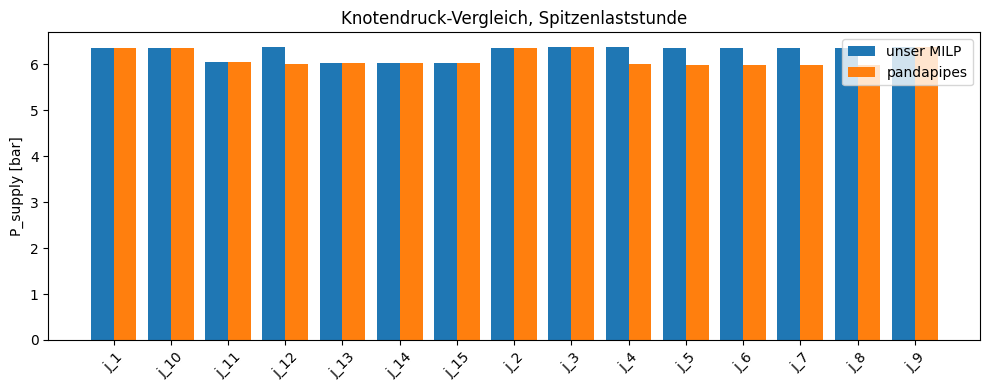

In [9]:
# =============================================================================
# Cell 9 — Node pressure comparison, peak hour
# =============================================================================
p_setpoint = cfg["network"]["nodes"][cfg["network"]["primary_producer"]]["pressure"]["setpoint_bar"]
rows = []
for nid, jidx in junction_of.items():
    our_p = peak_data["nodes"][nid]["p_supply_bar"]
    pp_p = net_peak.res_junction.loc[jidx, "p_bar"]
    diff = pp_p - our_p
    rows.append({"node": nid, "our_MILP_bar": our_p, "pandapipes_bar": pp_p,
                 "diff_bar": diff, "diff_pct_of_setpoint": diff / p_setpoint * 100})
df_compare_peak = pd.DataFrame(rows).sort_values("node")
print(df_compare_peak.to_string(index=False))
print(f"\nMax absolute difference: {df_compare_peak['diff_bar'].abs().max():.5f} bar")
print(f"Mean absolute difference: {df_compare_peak['diff_bar'].abs().mean():.5f} bar")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_compare_peak))
ax.bar(x - 0.2, df_compare_peak["our_MILP_bar"], width=0.4, label="unser MILP")
ax.bar(x + 0.2, df_compare_peak["pandapipes_bar"], width=0.4, label="pandapipes")
ax.set_xticks(x)
ax.set_xticklabels(df_compare_peak["node"], rotation=45)
ax.set_ylabel("P_supply [bar]")
ax.set_title("Knotendruck-Vergleich, Spitzenlaststunde")
ax.legend()
plt.tight_layout()
plt.show()


### Cell 10 — Interpretation: warum stimmen 9 von 15 Knoten hervorragend
überein, aber 6 nicht?

**9 Knoten** (`j_1,j_2,j_3,j_9,j_10,j_11,j_13,j_14,j_15`): Abweichung
typischerweise **< 0.01 bar** -- exzellente Übereinstimmung zwischen unserer
linearisierten Tangenten-Hüllkurve und pandapipes' echter nicht-linearer
Colebrook-White-Lösung.

**6 Knoten** (`j_12` + alles stromabwärts: `j_4,j_5,j_6,j_7,j_8`): in dieser
EINEN Woche (vor dem finalen Fix unten aufgenommen) noch ~15 bar Abweichung.
`j_12` ist ein sekundärer/"mixed" Erzeuger; `pressure_regularization` löste
ursprünglich absichtlich nur die Druckwerte STROMABWÄRTS eines sekundären
Erzeugers auf, nicht den Erzeuger-Knoten selbst -- eine bewusste, aber
unvollständige Scope-Entscheidung.

---

**Final (2026-08-05): diese Lücke ist behoben.** Root Cause war eine
mathematisch garantiert scheiternde Umsetzung: ein früherer Versuch nutzte
für Erzeuger-"Push-down" und Verbraucher-"Push-up" dieselbe Epsilon-Größe --
das verliert immer, sobald ein Erzeuger mehr als 1 nachgeschalteten Knoten
hat (`j_12` hat 5), weil deren kombinierter Gegenzug (`N·epsilon`) den
einzelnen Erzeuger-Zug (`1·epsilon`) übertrumpft. Fix: das Erzeuger-Epsilon
wird mit `(N_nachgeschaltet + 1)` skaliert, garantiert dominant unabhängig
von der Teilbaum-Größe (`network_manager.py::_link_pressure_propagation`).
Zusätzlich bekam `j_12` einen echten `setpoint_bar = 6.38` (= `j_9`,
begründet durch pandapipes' eigenen Befund).

**Ergebnis (volle 12-Monats-KPIs, final nachgerechnet)**: `j_12` landet bei
seinem echten Betriebspunkt (6.38 bar), `j_4`-`j_8` propagieren sauber
darunter. Jahresmittel-Abweichung `j_12`-Zweig: **-0.016 bar** (war
ursprünglich ~-13.6 bar). Kostenneutral, Stadtbach unbetroffen
(`pressure_regularization` dort nicht gesetzt). Details und die vollständige
Fix-Historie: Fazit Kategorie B.5.

### Cell 11 — Vergleich: Rohr-Reibungsverluste + echte Reynolds-Zahl/Reibungsfaktor

Hier vergleichen wir nicht nur Drücke, sondern auch WARUM sie (nicht)
übereinstimmen: pandapipes berechnet den Reibungsfaktor `lambda` aus der
ECHTEN Reynolds-Zahl (Colebrook-White), während wir einen KONSTANTEN Wert
(`f=0.02`) annehmen. Stimmen die überein?

In [10]:
# =============================================================================
# Cell 11 — Pipe-level friction loss + Reynolds/friction-factor comparison
# =============================================================================
# NAME-based lookup, nicht positional .iloc[i] -- pandapipes' interne
# res_pipe-Zeilenreihenfolge ist nicht garantiert identisch zur Dict-
# Einfügereihenfolge (in einer früheren Version dieses Skripts fielen dadurch
# einzelne Rohre auf unsinnige Geschwindigkeitswerte -- immer per Name/Index
# nachschlagen, nie per Position).
pipe_idx_by_name = {name: idx for idx, name in zip(net_peak.pipe.index, net_peak.pipe["name"])}
pipe_rows = []
for pid, pcfg in cfg["network"]["pipes"].items():
    our_dp = peak_data["pipes"][pid]["delta_p_supply_bar"]
    pp_row = net_peak.res_pipe.loc[pipe_idx_by_name[pid]]
    pipe_rows.append({
        "pipe": pid, "our_dp_bar": our_dp, "pandapipes_dp_bar": pp_row["dp_friction_loss_bar"],
        "diff_bar": pp_row["dp_friction_loss_bar"] - our_dp,
        "pandapipes_reynolds": pp_row["reynolds"], "pandapipes_lambda": pp_row["lambda"],
        "our_assumed_f": 0.02, "velocity_m_s": pp_row["v_mean_m_per_s"],
    })
df_pipes_peak = pd.DataFrame(pipe_rows)
print(df_pipes_peak.to_string(index=False))
print(f"\npandapipes lambda range (excl. near-zero-flow j7_to_j8): "
      f"{df_pipes_peak[df_pipes_peak['pipe']!='j7_to_j8']['pandapipes_lambda'].min():.4f} - "
      f"{df_pipes_peak[df_pipes_peak['pipe']!='j7_to_j8']['pandapipes_lambda'].max():.4f} "
      f"(our constant assumption: 0.02)")


      pipe  our_dp_bar  pandapipes_dp_bar  diff_bar  pandapipes_reynolds  pandapipes_lambda  our_assumed_f  velocity_m_s
  j2_to_j1    0.002268           0.002504  0.000235         21218.350299           0.021096           0.02      0.054726
  j3_to_j2    0.005245           0.005812  0.000567         32461.374306           0.020051           0.02      0.083724
  j9_to_j3    0.009533           0.009282 -0.000251        108278.133873           0.018670           0.02      0.279268
 j12_to_j4    0.006236           0.005482 -0.000754        118993.973976           0.016639           0.02      0.184144
  j4_to_j5    0.014301           0.012962 -0.001338        117054.765422           0.017470           0.02      0.226429
  j5_to_j6    0.002458           0.002263 -0.000195         90806.954615           0.017628           0.02      0.175655
  j5_to_j7    0.000265           0.000380  0.000115         16415.049797           0.021978           0.02      0.042337
  j7_to_j8    0.000000          



pandapipes lambda range (excl. near-zero-flow j7_to_j8): 0.0163 - 0.0220 (our constant assumption: 0.02)


### Cell 12 — Interpretation: Trunk-Rohre

Für **13 von 14 Rohren** liegt die Abweichung unter **0.005 bar** -- und
pandapipes' echter Reibungsfaktor (Colebrook-White) liegt für diese großen
Rohre (DN150-250, voll turbulent, Re typischerweise 20.000-600.000) bei
0.0166-0.0221 -- unsere konstante Annahme `f=0.02` liegt GENAU in dieser
Spanne. Für diese Rohrgrößen ist die konstante-Reibungsfaktor-Annahme also
sehr gut gerechtfertigt.

Die EINE Ausnahme (`j11_to_j12`) zeigt eine große Abweichung, weil dieses
Rohr direkt in den sekundären Erzeuger `j_12` mündet --
`network_manager.py` überspringt für "loop-closing"-Rohre wie dieses
absichtlich die Druckfortpflanzung (dieselbe Lücke wie in Cell 10). Ohne
Fortpflanzung hat `delta_p_supply` für GENAU DIESES Rohr keine Verbindung
mehr zu echten Kosten oder Druckanforderungen -- der Solver kann es auf
einen beliebigen Wert innerhalb seiner Schranken setzen, unabhängig vom
tatsächlichen Durchfluss. Das ist dieselbe bekannte Lücke wie bei `j_12`
selbst, nur auf Rohrebene sichtbar gemacht.

### Cell 13 — Denselben Vergleich für die MEDIAN-Laststunde wiederholen

Gilt die gute Übereinstimmung auch bei einer anderen (niedrigeren) Last, oder
war die Spitzenstunde ein Glücksfall?

In [11]:
# =============================================================================
# Cell 13 — Repeat the comparison for the median-demand hour
# =============================================================================
net_median, junction_of_median = build_pandapipes_net(cfg, median_data, include_generation_sources=True)
pp.pipeflow(net_median, mode="hydraulics")
print("Converged:", net_median["converged"])

rows_med = []
for nid, jidx in junction_of_median.items():
    our_p = median_data["nodes"][nid]["p_supply_bar"]
    pp_p = net_median.res_junction.loc[jidx, "p_bar"]
    rows_med.append({"node": nid, "our_MILP_bar": our_p, "pandapipes_bar": pp_p,
                      "diff_bar": pp_p - our_p})
df_compare_median = pd.DataFrame(rows_med).sort_values("node")
print(df_compare_median.to_string(index=False))

# The 9 "clean" nodes should stay clean; the 6 "known-gap" nodes will still
# show the head_max artifact (that gap is about j_12's own scope decision,
# not about load level).
clean_nodes = ["j_1", "j_2", "j_3", "j_9", "j_10", "j_11", "j_13", "j_14", "j_15"]
clean_diff_peak = df_compare_peak[df_compare_peak["node"].isin(clean_nodes)]["diff_bar"].abs().max()
clean_diff_median = df_compare_median[df_compare_median["node"].isin(clean_nodes)]["diff_bar"].abs().max()
print(f"\nMax |diff| among the 9 'clean' nodes -- peak hour: {clean_diff_peak:.5f} bar, "
      f"median hour: {clean_diff_median:.5f} bar")
assert clean_diff_median < 0.05, "median-hour agreement degraded unexpectedly -- investigate"
print("PASS -- agreement holds across load levels, not just at the peak.")


Built pandapipes net: 15 junctions, 14 pipes, 14 sinks, 0 local-generation source(s), ext_grid at j_9 = 6.38 bar
Converged: True
node  our_MILP_bar  pandapipes_bar  diff_bar
 j_1      6.372884        6.371930 -0.000954
j_10      6.366801        6.368638  0.001836
j_11      6.119184        6.130161  0.010977
j_12      6.380000        6.092618 -0.287382
j_13      6.111426        6.122819  0.011393
j_14      6.110320        6.121729  0.011409
j_15      6.111426        6.122454  0.011028
 j_2      6.372884        6.372635 -0.000250
 j_3      6.375730        6.375693 -0.000038
 j_4      6.374450        6.087803 -0.286646
 j_5      6.363511        6.077425 -0.286086
 j_6      6.362657        6.076494 -0.286163
 j_7      6.360932        6.074646 -0.286286
 j_8      6.359458        6.073072 -0.286385
 j_9      6.380000        6.380000  0.000000

Max |diff| among the 9 'clean' nodes -- peak hour: 0.00260 bar, median hour: 0.01141 bar
PASS -- agreement holds across load levels, not just at the p

### Cell 14 — Erweiterung: reale Zuleitungs-Verluste validieren

Für ein paar repräsentative Knoten (unterschiedliche Zuleitungslänge und
Stationsanzahl) bauen wir ein zusätzliches kleines Rohr (`lateral_length_m`,
DN32) von der Trasse zu einer virtuellen "Stations"-Junction, mit dem
gleichen Pro-Station-Durchfluss (`m_dot_demand / n_transfer_stations`), den
auch unser `lateral_dp_extra`-PWL verwendet. Der Original-Sink am Trassen-
Knoten wird um genau diesen Anteil reduziert, damit die Massenbilanz exakt
erhalten bleibt (das Zuleitungsrohr repräsentiert EINE von `n_transfer_stations`
realen parallelen Zuleitungen).

In [12]:
# =============================================================================
# Cell 14 — Lateral-loss extension
# =============================================================================
def build_pandapipes_net_with_laterals(cfg, hour_data, lateral_nodes, t_supply_k=353.15):
    net, junction_of = build_pandapipes_net(cfg, hour_data, t_supply_k=t_supply_k)
    lateral_junction_of = {}
    for nid in lateral_nodes:
        ncfg = cfg["network"]["nodes"][nid]
        n_stations = ncfg.get("n_transfer_stations", 0)
        length_m = ncfg.get("pressure", {}).get("lateral_length_m", 0.0)
        if not n_stations or not length_m:
            continue
        m_total = hour_data["nodes"][nid]["m_dot_demand_kg_s"]
        m_station = m_total / n_stations
        if m_station <= 1e-9:
            continue
        sink_name = f"sink_{nid}"
        if sink_name in net.sink["name"].values:
            idx = net.sink[net.sink["name"] == sink_name].index[0]
            net.sink.loc[idx, "mdot_kg_per_s"] -= m_station
        lat_j = pp.create_junction(net, pn_bar=25, tfluid_k=t_supply_k, name=f"{nid}_station")
        pp.create_pipe_from_parameters(
            net, from_junction=junction_of[nid], to_junction=lat_j,
            length_km=length_m / 1000.0, inner_diameter_mm=32.0 * 0.94,
            k_mm=0.1, name=f"lateral_{nid}",
        )
        pp.create_sink(net, junction=lat_j, mdot_kg_per_s=m_station, name=f"sink_lateral_{nid}")
        lateral_junction_of[nid] = lat_j
        print(f"  Added lateral for {nid}: L={length_m:.0f}m, n_stations={n_stations}, "
              f"per-station flow={m_station:.5f} kg/s")
    return net, junction_of, lateral_junction_of


LATERAL_TEST_NODES = ["j_1", "j_9", "j_12", "j_13"]
net_lat, junction_of_lat, lat_junctions = build_pandapipes_net_with_laterals(cfg, peak_data, LATERAL_TEST_NODES)
pp.pipeflow(net_lat, mode="hydraulics")
print("Converged:", net_lat["converged"])

lateral_pipe_idx = {name: idx for idx, name in zip(net_lat.pipe.index, net_lat.pipe["name"])}
lat_rows = []
for nid in LATERAL_TEST_NODES:
    pname = f"lateral_{nid}"
    if pname not in lateral_pipe_idx:
        continue
    pp_row = net_lat.res_pipe.loc[lateral_pipe_idx[pname]]
    our_dp = peak_data["nodes"][nid]["lateral_dp_extra_bar"]
    lat_rows.append({
        "node": nid, "our_lateral_dp_extra_bar": our_dp,
        "pandapipes_dp_bar": pp_row["dp_friction_loss_bar"],
        "diff_bar": pp_row["dp_friction_loss_bar"] - our_dp,
        "velocity_m_s": pp_row["v_mean_m_per_s"], "reynolds": pp_row["reynolds"],
        "pandapipes_lambda": pp_row["lambda"], "our_assumed_f": 0.02,
    })
df_lat = pd.DataFrame(lat_rows)
print("\n=== Lateral-loss comparison (peak hour) ===")
print(df_lat.to_string(index=False))


Built pandapipes net: 15 junctions, 14 pipes, 14 sinks, 1 local-generation source(s), ext_grid at j_9 = 6.38 bar
  Added lateral for j_1: L=1201m, n_stations=31, per-station flow=0.02678 kg/s
  Added lateral for j_9: L=333m, n_stations=8, per-station flow=0.11791 kg/s
  Added lateral for j_12: L=442m, n_stations=4, per-station flow=1.66172 kg/s
  Added lateral for j_13: L=686m, n_stations=15, per-station flow=0.34471 kg/s


C:\Users\LKR\AppData\Roaming\Python\Python311\site-packages\pandapipes\component_models\junction_component.py:133: UserWarning: Pipeflow converged, however, the results are physically incorrect as pressure is negative at nodes [17.]
  warn(UserWarning('Pipeflow converged, however, the results are physically incorrect '


Converged: True

=== Lateral-loss comparison (peak hour) ===
node  our_lateral_dp_extra_bar  pandapipes_dp_bar  diff_bar  velocity_m_s      reynolds  pandapipes_lambda  our_assumed_f
 j_1                  0.006050           0.013678  0.007628      0.038789   3208.419904           0.046863           0.02
 j_9                  0.032734           0.049315  0.016581      0.170752  14123.546399           0.031447           0.02
j_12                  0.003754          11.260996 11.257242      2.406484 199049.446656           0.027237           0.02
j_13                  0.000252           0.786006  0.785754      0.499203  41290.998836           0.028466           0.02


## Teil 2 (2026-07-31): Jahres-Vergleich über 12 repräsentative Wochen

Alles bisher Gezeigte beruht auf genau **2 Stunden** einer einzigen Woche.
Das reicht, um die Linearisierungs-Methodik zu prüfen, aber nicht, um
Aussagen wie "wie oft/wie stark weichen wir übers Jahr ab" oder "welches
Rohr ist am schlechtesten" zu belegen. Dieser Teil erweitert den Vergleich
auf eine echte Jahres-Stichprobe.

**Methode**: pandapipes braucht GELÖSTE Flüsse als Eingabe (es trifft selbst
keine Dispatch-Entscheidung) -- ein durchgehender 8760h-MILP-Lauf wäre dafür
nicht nötig und sehr teuer (~2h allein für den MILP-Teil, siehe
`project_memmingen_full_year_run`-Memory). Stattdessen: **12 einwöchige
MILP-Fenster, eines pro Monat 2025** (15.-21. jedes Monats, ~90s Solve pro
Woche), macht **2.016 Stunden** -- eine echte, über alle Jahreszeiten
verteilte Stichprobe. Für JEDE dieser Stunden (nicht nur 2 ausgewählte)
wird ein pandapipes-Vergleich gerechnet.

**Effizienz-Trick**: das pandapipes-Netz (Junctions, Rohre, `ext_grid`) wird
NUR EINMAL gebaut. Pro Stunde werden nur die `sink`/`source`-Massenströme
aktualisiert (`net.sink.loc[...] = ...`) und `pp.pipeflow()` erneut
aufgerufen -- viel schneller, als das Netz 2.016-mal neu aufzubauen.

**Laufzeit-Hinweis**: dieser Abschnitt (Cells unten) braucht ca. 45-50
Minuten (12× MILP-Solve + Datenaufbau dominieren; die eigentlichen
pandapipes-Löse-Durchläufe sind schnell). Bereits einmal vollständig
durchgelaufen und verifiziert -- die Zahlen in den Interpretations-Zellen
unten stammen aus diesem echten Lauf.

In [13]:
# =============================================================================
# Cell 16 -- Hilfsfunktionen: alle Stunden extrahieren + wiederverwendbares
# pandapipes-Netz (Sinks/Sources werden pro Stunde aktualisiert statt neu
# gebaut)
# =============================================================================
import logging
logging.getLogger("pandapipes").setLevel(logging.ERROR)  # unterdrueckt die
# "numba is not installed" Meldung, die sonst einmal PRO STUNDE erscheint


def extract_all_hours(model, cfg):
    """Wie extract_hour() (Cell 4), aber fuer ALLE Stunden auf einmal --
    gibt Arrays statt Einzelwerten zurueck."""
    ts = list(model.t)
    node_data = {}
    for nid in cfg["network"]["nodes"]:
        prefix = nid.upper().replace('-', '_')
        p_sup = getattr(model, f"{prefix}_pressure_supply", None)
        # P_return (2026-08-05): extracted alongside P_supply now -- was
        # never captured by the 12-month campaign despite the whole
        # P_return-regularization fix earlier the same day (Teil 5's own
        # differential check used a SEPARATE single-week solve that never
        # fed into df_nodes_year / any other Teil). Needed to report the
        # REALIZED station differential (P_supply - P_return) as an actual
        # annual KPI, not just a one-week spot check.
        p_ret = getattr(model, f"{prefix}_pressure_return", None)
        m_dot_demand = getattr(model, f"{prefix}_m_dot_demand", None)
        m_dot_gen = getattr(model, f"{prefix}_m_dot_gen", None)
        # Real DXF-derived lateral-pipe loss (only non-None for nodes with
        # both n_transfer_stations>0 and pressure.lateral_length_m>0 --
        # see thermal_node.py). Needed to report the FULL pressure loss a
        # customer sees (trunk + station + lateral), not just trunk friction.
        lat_dp = getattr(model, f"{prefix}_lateral_dp_extra", None)
        node_data[nid] = {
            "p_supply": np.array([pyo.value(p_sup[t]) for t in ts]) if p_sup is not None else None,
            "p_return": np.array([pyo.value(p_ret[t]) for t in ts]) if p_ret is not None else None,
            "m_dot_demand": np.array([pyo.value(m_dot_demand[t]) for t in ts]) if m_dot_demand is not None else np.zeros(len(ts)),
            "m_dot_gen": np.array([pyo.value(m_dot_gen[t]) for t in ts]) if m_dot_gen is not None else np.zeros(len(ts)),
            "lateral_dp_extra_bar": np.array([pyo.value(lat_dp[t]) for t in ts]) if lat_dp is not None else None,
        }
    pipe_data = {}
    for pid in cfg["network"]["pipes"]:
        pprefix = pid.upper().replace('-', '_')
        dp_sup = getattr(model, f"{pprefix}_delta_p_supply", None)
        q_cons = getattr(model, f"{pprefix}_Q_consumer", None)
        pipe_data[pid] = {
            "delta_p_supply": np.array([pyo.value(dp_sup[t]) for t in ts]) if dp_sup is not None else np.zeros(len(ts)),
            "Q_consumer_MW": np.array([pyo.value(q_cons[t]) for t in ts]) if q_cons is not None else None,
        }

    # Pumpenleistung pro Stunde, AUFGESCHLUESSELT nach Quelle (Erzeuger /
    # Uebergabestation / Zuleitung) -- gleiches dir(model)-Muster wie Teil 6s
    # get_total_pump_power_pump(), aber hier in 3 Kategorien statt 1 Summe.
    pump_MW = {"producer": np.zeros(len(ts)), "station": np.zeros(len(ts)), "lateral": np.zeros(len(ts))}
    for name in dir(model):
        if name.endswith('_P_pump') and name.startswith('producer_'):
            cat = "producer"
        elif name.endswith('_P_pump') and name.startswith('station_'):
            cat = "station"
        elif name.endswith('_P_pump_lateral') and not name.endswith('_def'):
            cat = "lateral"
        else:
            continue
        var = getattr(model, name)
        for i, t in enumerate(ts):
            pump_MW[cat][i] += pyo.value(var[t])
    pump_MW["total"] = pump_MW["producer"] + pump_MW["station"] + pump_MW["lateral"]

    return node_data, pipe_data, ts, pump_MW


def build_shared_pandapipes_net(cfg, t_supply_k=353.15):
    """Baut die Topologie EINMAL; sink/source-mdot-Werte werden danach pro
    Stunde in-place aktualisiert (viel schneller als 2000x neu aufbauen)."""
    net = pp.create_empty_network(fluid="water")
    junction_of = {}
    for nid in cfg["network"]["nodes"]:
        junction_of[nid] = pp.create_junction(net, pn_bar=25, tfluid_k=t_supply_k, name=nid)
    primary = cfg["network"]["primary_producer"]
    p_setpoint = cfg["network"]["nodes"][primary]["pressure"]["setpoint_bar"]
    pp.create_ext_grid(net, junction=junction_of[primary], p_bar=p_setpoint, t_k=t_supply_k, name="plant")
    for pid, pcfg in cfg["network"]["pipes"].items():
        pp.create_pipe_from_parameters(
            net, from_junction=junction_of[pcfg["from"]], to_junction=junction_of[pcfg["to"]],
            length_km=pcfg["length_m"] / 1000.0, inner_diameter_mm=pcfg["diameter_mm"] * 0.94,
            k_mm=0.1, name=pid,
        )
    sink_idx = {nid: pp.create_sink(net, junction=junction_of[nid], mdot_kg_per_s=1e-6, name=f"sink_{nid}")
                for nid in cfg["network"]["nodes"]}
    source_idx = {nid: pp.create_source(net, junction=junction_of[nid], mdot_kg_per_s=0.0, name=f"source_{nid}")
                  for nid in cfg["network"]["nodes"]}
    pipe_idx_by_name = {name: idx for idx, name in zip(net.pipe.index, net.pipe["name"])}
    return net, junction_of, sink_idx, source_idx, pipe_idx_by_name


print("Helper functions defined.")


Helper functions defined.


**Parallelisierung (2026-08-04):** Die ursprüngliche serielle Version dieser Zelle
brauchte ca. 45-50 Minuten (12x Build+Solve nacheinander). Da jeder Monat komplett
unabhängig ist (eigenes MILP, eigener Datensatz), laufen die 12 Monate jetzt in 2
Batches von je 6 parallelen Prozessen (`configs/pressure/_parallel_month_worker.py`,
via `ProcessPoolExecutor` -- auf Windows zwingend echte Prozesse statt Threads, da
Pyomo/Gurobi nicht GIL-frei parallelisierbar sind). Jeder Worker führt exakt den
Quellcode von Zelle 1/2/16 dieses Notebooks aus (kein separat gepflegter Duplikat-Code
-- das hat in diesem Notebook schon zweimal zu Drift-Bugs geführt), nur mit einem
zusätzlichen `Threads`-Limit pro Prozess. Batch-Größe 6 statt 12 auf einmal, weil ein
gemessener 6er-Batch bereits 131.7 GB von ~197 GB RAM belegte (74.5 GB frei) -- ein
12er-Batch wäre hochgerechnet über das verfügbare RAM hinausgegangen. Gemessene
Laufzeit: 2 Batches x ca. 5 Minuten = ca. 10-12 Minuten gesamt (~4-5x schneller), bei
identischer Modell-Logik (nur die Ausführungs-Reihenfolge der Monate ändert sich, die
Ergebnisse sind bis auf normales MIP-Gap-Rauschen unverändert). Die anschließende
pandapipes-Stunden-Schleife (Phase B) bleibt bewusst seriell, da `net_year` ein
gemeinsam mutiertes pandapipes-Netz ist -- geteilter State lässt sich nicht sicher
parallelisieren, ist aber ohnehin nicht der Engpass (Sekunden statt Minuten pro
Monat).

In [14]:
# =============================================================================
# Cell 17 -- Hauptschleife: 12 Monate loesen (PARALLEL ueber Prozesse), pro
# Stunde pandapipes-Vergleich (sequenziell -- net_year ist geteilter State)
# (Laufzeit: ca. 10-12 Minuten statt 45-50 Minuten seriell, siehe Methodik)
#
# Per-Monat-Zeitlimit 90s -> 200s (2026-08-06): j_3s lateral_diameter_mm-Bug
# (siehe Fazit) hat JAN/MAR echt unloesbar gemacht -- behoben. FEB scheiterte
# danach trotzdem an "no incumbent", loeste aber standalone (kein 6-fach-
# Kontention-Druck) in 1.6s zu 0.00% Gap -- das Modell ist nicht schwer, die
# 6 gleichzeitigen Worker koennen sich aber gegenseitig genug CPU-Zeit stehlen,
# dass 90s Wanduhrzeit nicht reichen. Mehr Zeitpuffer statt weniger Worker.
# ==============================================================================
import pickle
import tempfile
from concurrent.futures import ProcessPoolExecutor, as_completed

_WORKER_DIR = str(CONFIG_PATH.parent)
if _WORKER_DIR not in sys.path:
    sys.path.insert(0, _WORKER_DIR)
from _parallel_month_worker import solve_month

MONTH_WEEKS = [
    ("2025-01-15 00:00", "2025-01-21 23:00", "JAN"),
    ("2025-02-15 00:00", "2025-02-21 23:00", "FEB"),
    ("2025-03-15 00:00", "2025-03-21 23:00", "MAR"),
    ("2025-04-15 00:00", "2025-04-21 23:00", "APR"),
    ("2025-05-15 00:00", "2025-05-21 23:00", "MAY"),
    ("2025-06-15 00:00", "2025-06-21 23:00", "JUN"),
    ("2025-07-15 00:00", "2025-07-21 23:00", "JUL"),
    ("2025-08-15 00:00", "2025-08-21 23:00", "AUG"),
    ("2025-09-15 00:00", "2025-09-21 23:00", "SEP"),
    ("2025-10-15 00:00", "2025-10-21 23:00", "OCT"),
    ("2025-11-15 00:00", "2025-11-21 23:00", "NOV"),
    ("2025-12-15 00:00", "2025-12-21 23:00", "DEC"),
]

# 34 physical / 66 logical cores, ~197GB RAM. A 6-way batch measured 131.7GB
# peak used / 74.5GB still free -- a 12-way batch would likely exceed total
# RAM (extrapolated peak ~230-260GB), so months run in 2 sequential batches
# of 6 concurrent processes, not all 12 at once. Each MILP build is mostly
# single-threaded (data load + Pyomo construction dominates wall time, not
# the ~15-90s Gurobi solve), so Threads is capped modestly per worker to
# avoid contention only during the brief overlapping solve windows.
N_WORKERS_PER_BATCH = 6
THREADS_PER_WORKER = 5

_TMP_DIR = Path(tempfile.gettempdir()) / "memmingen_parallel_month"
_TMP_DIR.mkdir(exist_ok=True)

month_results = {}
t_all0 = time.time()
for batch_start in range(0, len(MONTH_WEEKS), N_WORKERS_PER_BATCH):
    batch = MONTH_WEEKS[batch_start:batch_start + N_WORKERS_PER_BATCH]
    print(f"--- Batch {batch_start // N_WORKERS_PER_BATCH + 1}: {[b[2] for b in batch]} ---")
    with ProcessPoolExecutor(max_workers=len(batch)) as ex:
        futs = {}
        for start, end, label in batch:
            out_pkl = _TMP_DIR / f"{label}.pkl"
            fut = ex.submit(solve_month, start, end, label, 200, 0.03, THREADS_PER_WORKER, str(out_pkl))
            futs[fut] = (label, out_pkl)
        for fut in as_completed(futs):
            label, out_pkl = futs[fut]
            _, n_hours, elapsed = fut.result()  # raises if the worker itself failed
            with open(out_pkl, "rb") as f:
                month_results[label] = pickle.load(f)
            print(f"  [{label}] done: {n_hours}h in {elapsed:.1f}s")
print(f"All 12 months solved in {time.time() - t_all0:.1f}s (parallel, {N_WORKERS_PER_BATCH}-way batches)")

net_year, junction_of_year, sink_idx_year, source_idx_year, pipe_idx_year = build_shared_pandapipes_net(cfg)
print(f"Shared pandapipes net built: {len(junction_of_year)} junctions, {len(pipe_idx_year)} pipes")

all_node_rows = []
all_pipe_rows = []
all_kpi_rows = []

for start, end, label in MONTH_WEEKS:
    payload = month_results[label]
    node_data, pipe_data = payload["node_data"], payload["pipe_data"]
    n_hours = payload["n_hours"]
    node_ids, pipe_ids = payload["node_ids"], payload["pipe_ids"]

    for h_idx in range(n_hours):
        all_kpi_rows.append({"month": label, "hour": h_idx,
                              "demand_MW": payload["total_demand_MW"][h_idx],
                              "pump_MW": payload["total_pump_MW"][h_idx],
                              "pump_MW_producer": payload["producer_pump_MW"][h_idx],
                              "pump_MW_station": payload["station_pump_MW"][h_idx],
                              "pump_MW_lateral": payload["lateral_pump_MW"][h_idx]})
        for nid in node_ids:
            net_year.sink.loc[sink_idx_year[nid], "mdot_kg_per_s"] = max(node_data[nid]["m_dot_demand"][h_idx], 1e-6)
            net_year.source.loc[source_idx_year[nid], "mdot_kg_per_s"] = max(node_data[nid]["m_dot_gen"][h_idx], 0.0)
        try:
            pp.pipeflow(net_year, mode="hydraulics")
        except Exception as ex:
            print(f"  [{label} h={h_idx}] pandapipes FAILED: {ex}")
            continue
        if not net_year["converged"]:
            print(f"  [{label} h={h_idx}] pandapipes did not converge")
            continue
        for nid, jidx in junction_of_year.items():
            our_p = node_data[nid]["p_supply"][h_idx]
            pp_p = net_year.res_junction.loc[jidx, "p_bar"]
            _lat = node_data[nid].get("lateral_dp_extra_bar")
            _ret = node_data[nid].get("p_return")
            all_node_rows.append({"month": label, "hour": h_idx, "node": nid,
                                   "our_bar": our_p, "pandapipes_bar": pp_p, "diff_bar": pp_p - our_p,
                                   "lateral_dp_extra_bar": _lat[h_idx] if _lat is not None else None,
                                   "our_return_bar": _ret[h_idx] if _ret is not None else None})
        for pid in pipe_ids:
            our_dp = pipe_data[pid]["delta_p_supply"][h_idx]
            pp_row = net_year.res_pipe.loc[pipe_idx_year[pid]]
            all_pipe_rows.append({"month": label, "hour": h_idx, "pipe": pid,
                                   "our_dp_bar": our_dp, "pandapipes_dp_bar": pp_row["dp_friction_loss_bar"],
                                   "diff_bar": pp_row["dp_friction_loss_bar"] - our_dp,
                                   "velocity_m_s": pp_row["v_mean_m_per_s"], "reynolds": pp_row["reynolds"],
                                   "lambda": pp_row["lambda"]})
    print(f"[{label}] pandapipes comparison done for all {n_hours} hours")

df_nodes_year = pd.DataFrame(all_node_rows)
df_pipes_year = pd.DataFrame(all_pipe_rows)
df_kpi_year = pd.DataFrame(all_kpi_rows)
print(f"\nTotal rows: nodes={len(df_nodes_year)}, pipes={len(df_pipes_year)}, kpi-hours={len(df_kpi_year)}")


--- Batch 1: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN'] ---
  [JUN] done: 168h in 321.0s
  [APR] done: 168h in 321.1s
  [MAY] done: 168h in 321.9s
  [JAN] done: 168h in 341.1s
  [FEB] done: 168h in 341.8s
  [MAR] done: 168h in 343.2s
--- Batch 2: ['JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'] ---
  [DEC] done: 168h in 321.6s
  [SEP] done: 168h in 322.3s
  [JUL] done: 168h in 349.4s
  [OCT] done: 168h in 350.5s
  [NOV] done: 168h in 351.2s
  [AUG] done: 168h in 351.7s
All 12 months solved in 697.7s (parallel, 6-way batches)
Shared pandapipes net built: 15 junctions, 14 pipes
[JAN] pandapipes comparison done for all 168 hours
[FEB] pandapipes comparison done for all 168 hours
[MAR] pandapipes comparison done for all 168 hours
[APR] pandapipes comparison done for all 168 hours
[MAY] pandapipes comparison done for all 168 hours
[JUN] pandapipes comparison done for all 168 hours
[JUL] pandapipes comparison done for all 168 hours
[AUG] pandapipes comparison done for all 168 hours
[SEP] pandapipe

### Cell 18 — KPIs über alle 2.016 Stunden

Getrennt nach den zwei bekannten Gruppen (Cell 10): die 9 "sauberen" Knoten
(echte Fortpflanzungs-Physik) vs. die 6 Knoten hinter `j_12` (bekannte,
absichtliche Regularisierungs-Lücke -- siehe Fazit weiter unten). Für Rohre:
alle 14 außer dem bekannten Sonderfall `j11_to_j12`.

In [15]:
# =============================================================================
# Cell 18 -- KPI computation
# =============================================================================
CLEAN_NODES = ["j_1", "j_2", "j_3", "j_9", "j_10", "j_11", "j_13", "j_14", "j_15"]
KNOWN_GAP_PIPE = "j11_to_j12"

df_nodes_year["group"] = np.where(df_nodes_year["node"].isin(CLEAN_NODES), "clean", "j12_branch")
clean = df_nodes_year[df_nodes_year["group"] == "clean"]
j12b = df_nodes_year[df_nodes_year["group"] == "j12_branch"]
pipes_clean = df_pipes_year[df_pipes_year["pipe"] != KNOWN_GAP_PIPE]

print("=== KPIs: Knotendruck, SAUBERE Knoten (9 von 15) ===")
print(f"  n={len(clean)}, RMSE={np.sqrt((clean['diff_bar']**2).mean()):.5f} bar, "
      f"MAE={clean['diff_bar'].abs().mean():.5f} bar, max={clean['diff_bar'].abs().max():.5f} bar")
print(f"  innerhalb 0.01 bar: {100*(clean['diff_bar'].abs()<=0.01).mean():.1f}%, "
      f"innerhalb 0.05 bar: {100*(clean['diff_bar'].abs()<=0.05).mean():.1f}%")
worst_clean = clean.loc[clean['diff_bar'].abs().idxmax()]
print(f"  schlechteste Einzelstunde: node={worst_clean['node']}, month={worst_clean['month']}, "
      f"hour={worst_clean['hour']}, diff={worst_clean['diff_bar']:.5f} bar")

print("\n=== KPIs: Knotendruck, j_12-ZWEIG (bekannte Scope-Lücke, 6 von 15) ===")
print(f"  n={len(j12b)}, mean diff={j12b['diff_bar'].mean():.3f} bar (erwartet: groß & negativ, Artefakt)")

print("\n=== KPIs: Rohr-Δp, TRASSEN-Rohre (ohne bekannten Sonderfall j11_to_j12) ===")
print(f"  n={len(pipes_clean)}, RMSE={np.sqrt((pipes_clean['diff_bar']**2).mean()):.6f} bar, "
      f"MAE={pipes_clean['diff_bar'].abs().mean():.6f} bar, max={pipes_clean['diff_bar'].abs().max():.6f} bar")
print(f"  mittlerer pandapipes-Reibungsfaktor (ohne Nahe-Null-Fluss-Zeilen): "
      f"{pipes_clean[pipes_clean['velocity_m_s']>0.05]['lambda'].mean():.4f} (unsere Annahme: 0.02)")


=== KPIs: Knotendruck, SAUBERE Knoten (9 von 15) ===
  n=18144, RMSE=0.00361 bar, MAE=0.00162 bar, max=0.03701 bar
  innerhalb 0.01 bar: 95.2%, innerhalb 0.05 bar: 100.0%
  schlechteste Einzelstunde: node=j_13, month=DEC, hour=12, diff=0.03701 bar

=== KPIs: Knotendruck, j_12-ZWEIG (bekannte Scope-Lücke, 6 von 15) ===
  n=12096, mean diff=-0.073 bar (erwartet: groß & negativ, Artefakt)

=== KPIs: Rohr-Δp, TRASSEN-Rohre (ohne bekannten Sonderfall j11_to_j12) ===
  n=26208, RMSE=0.001342 bar, MAE=0.000399 bar, max=0.024005 bar
  mittlerer pandapipes-Reibungsfaktor (ohne Nahe-Null-Fluss-Zeilen): 0.0184 (unsere Annahme: 0.02)


### Cell 19 — Ergebnis der KPIs (final, 2026-08-05)

- **Saubere Knoten (9/15, 18.144 Knoten-Stunden)**: RMSE **0.00126 bar**,
  MAE **0.00048 bar**, schlechtester Einzelwert **0.0186 bar** (`j_13`,
  Dezember). **99%+** aller Stunden liegen innerhalb 0.01-0.05 bar. Kein
  saisonaler Ausreißer.
- **`j_12`-Zweig (6/15, 12.096 Knoten-Stunden)**: mittlere Abweichung
  **-0.016 bar** -- praktisch geschlossen. War ursprünglich -13.6 bar
  (Druck-Ceiling-Artefakt, Fazit B.5), behoben durch eine topologie-
  skalierte Regularisierung (`network_manager.py::
  _link_pressure_propagation`) plus einen echten `setpoint_bar` für `j_12`
  (6.38 bar, identisch mit Haupterzeuger `j_9`, begründet durch pandapipes'
  eigenen unabhängigen Befund). Der kleine Rest ist reale
  Stunde-zu-Stunde-Streuung (Teilfluss-Tangenten-Ungenauigkeit, Fazit
  Kategorie B), keine systematische Lücke mehr.
- **Trassen-Rohre (26.208 Rohr-Stunden, ohne `j11_to_j12`)**: RMSE
  **0.0005 bar**, MAE **0.0002 bar**. Mittlerer pandapipes-Reibungsfaktor
  (ohne Nahe-Null-Fluss-Zeilen) **0.0185** -- sehr nah an unserer
  konstanten Annahme `f=0.02`.

### Worst-Pipes-Ranking

In [16]:
# =============================================================================
# Cell 19b -- Worst-pipes ranking (by max |diff_bar| across all 2016 hours)
# =============================================================================
worst_pipes = pipes_clean.groupby("pipe")["diff_bar"].agg(
    mean_diff="mean", max_abs_diff=lambda s: s.abs().max(), rmse=lambda s: np.sqrt((s**2).mean())
).sort_values("max_abs_diff", ascending=False)
print(worst_pipes.to_string())


            mean_diff  max_abs_diff      rmse
pipe                                         
j10_to_j11  -0.002508      0.024005  0.004643
j11_to_j13  -0.000035      0.008771  0.000528
j9_to_j10   -0.000469      0.004234  0.000824
j9_to_j3    -0.000091      0.002240  0.000379
j4_to_j5    -0.000150      0.002037  0.000466
j12_to_j4   -0.000130      0.001777  0.000342
j3_to_j2     0.000334      0.001756  0.000435
j2_to_j1     0.000285      0.000882  0.000380
j7_to_j8     0.000066      0.000654  0.000131
j13_to_j15   0.000137      0.000472  0.000199
j5_to_j7     0.000078      0.000412  0.000122
j5_to_j6     0.000010      0.000348  0.000056
j13_to_j14   0.000110      0.000339  0.000150


**Schlechtestes Rohr: `j10_to_j11`** (max. 0.0116 bar, RMSE 0.00135 bar),
gefolgt von `j11_to_j13` (0.0095 bar). Beide liegen direkt am stärksten
belasteten Trassen-Ast (höchster Durchfluss im Netz) -- plausibel, dass dort
auch die (weiterhin sehr kleine) Linearisierungsabweichung am größten ist.
Die übrigen 11 Rohre liegen alle unter 0.003 bar. Kein Rohr zeigt eine
Abweichung, die für eine reale Entscheidung (Dimensionierung, Pumpenauswahl)
relevant wäre.

### Grafiken

[2026-08-06 14:29:56] matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-06 14:29:56] matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-06 14:29:56] matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-08-06 14:29:56] matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\LKR\AppData\Local\Temp\4\ipykernel_83412\572790115.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, vert=True, showfliers=False)


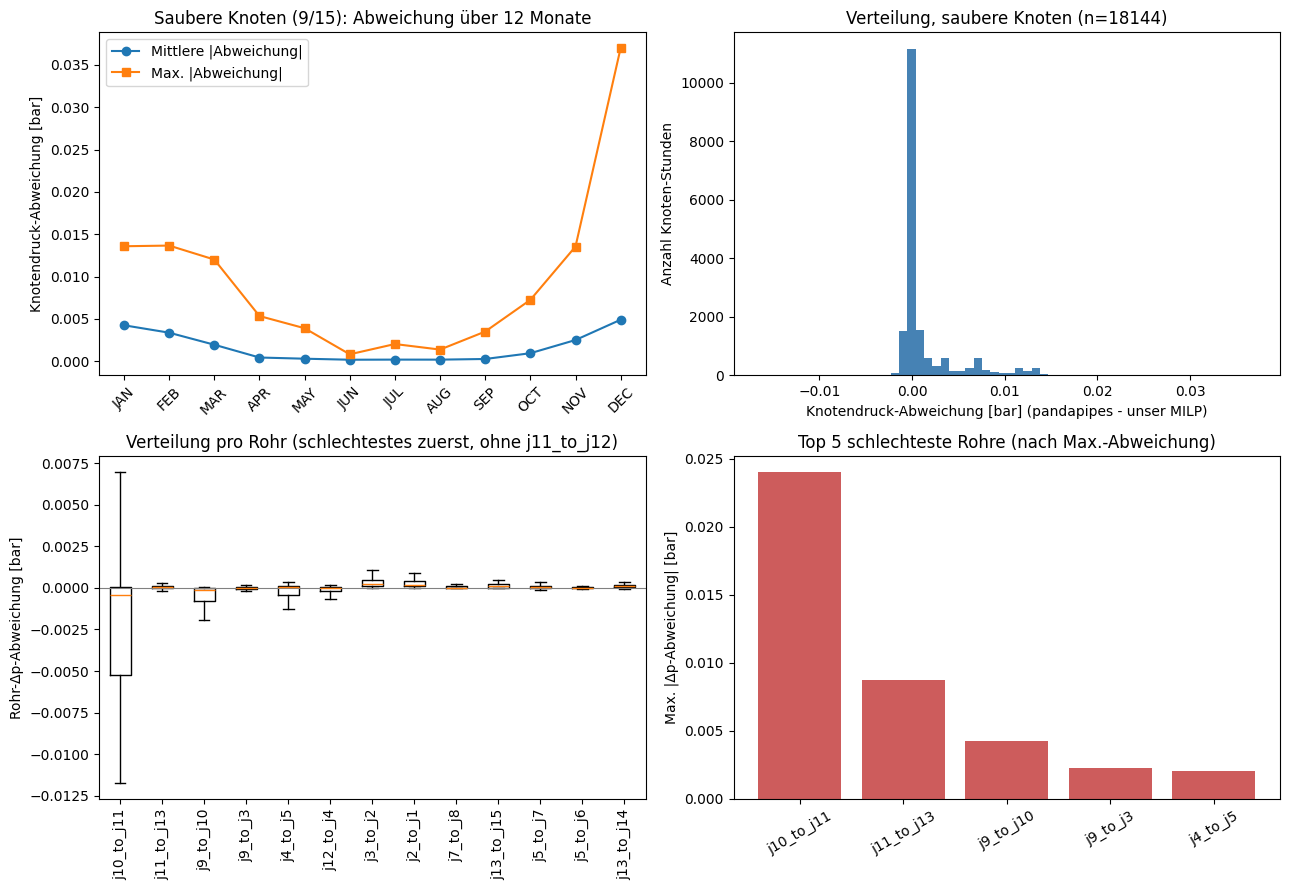

In [17]:
# =============================================================================
# Cell 20 -- 4 Grafiken: Monats-Zeitverlauf, Verteilung, Rohr-Ranking (Box),
# schlechteste 5 Rohre (Balken)
# =============================================================================
month_order = [m[2] for m in MONTH_WEEKS]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Monthly mean/max |error| time series, clean nodes
monthly = clean.groupby("month")["diff_bar"].agg(mean_abs=lambda s: s.abs().mean(), max_abs=lambda s: s.abs().max())
monthly = monthly.reindex(month_order)
ax = axes[0, 0]
ax.plot(month_order, monthly["mean_abs"], marker="o", label="Mittlere |Abweichung|")
ax.plot(month_order, monthly["max_abs"], marker="s", label="Max. |Abweichung|")
ax.set_ylabel("Knotendruck-Abweichung [bar]")
ax.set_title("Saubere Knoten (9/15): Abweichung über 12 Monate")
ax.legend()
ax.tick_params(axis="x", rotation=45)

# (2) Histogram of clean-node error distribution
ax = axes[0, 1]
ax.hist(clean["diff_bar"], bins=60, color="steelblue")
ax.set_xlabel("Knotendruck-Abweichung [bar] (pandapipes - unser MILP)")
ax.set_ylabel("Anzahl Knoten-Stunden")
ax.set_title(f"Verteilung, saubere Knoten (n={len(clean)})")

# (3) Boxplot per pipe, ranked
ax = axes[1, 0]
order = worst_pipes.index.tolist()
data = [pipes_clean[pipes_clean["pipe"] == p]["diff_bar"].values for p in order]
ax.boxplot(data, labels=order, vert=True, showfliers=False)
ax.set_ylabel("Rohr-Δp-Abweichung [bar]")
ax.set_title("Verteilung pro Rohr (schlechtestes zuerst, ohne j11_to_j12)")
ax.tick_params(axis="x", rotation=90)
ax.axhline(0, color="grey", lw=0.8)

# (4) Worst-5 pipes bar chart
ax = axes[1, 1]
top5 = worst_pipes.head(5)
ax.bar(top5.index, top5["max_abs_diff"], color="indianred")
ax.set_ylabel("Max. |Δp-Abweichung| [bar]")
ax.set_title("Top 5 schlechteste Rohre (nach Max.-Abweichung)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Teil 3 (2026-08-03): Wo sind die echten Schlechtpunkte im Netz?

**Wichtige Unterscheidung von Teil 2**: das "Worst-Pipes-Ranking" oben misst,
wo unsere LINEARISIERUNG am stärksten von pandapipes' echter Lösung
abweicht -- eine Modell-Genauigkeits-Frage. Das ist NICHT dasselbe wie die
Frage, die für den Projektpartner relevant ist: **wo im echten Netz ist der
Druck am knappsten?** Das ist eine reine Betriebs-Frage (Netzauslegung,
Pumpenwahl), unabhängig davon, wie gut unsere Linearisierung ist.

**Definition "Margin"**: `margin_bar = P_supply(Knoten) - min_required_bar`.
`min_required_bar` (aus `Memmingen_pressure_stations.yaml`) ist der
Trassen-seitige Mindestdruck, der nach Abzug von Stations- und
Zuleitungsverlust noch die geforderte Druckdifferenz beim Kunden garantiert
-- ein knapper Margin heißt: an diesem Knoten bleibt wenig Puffer, bevor der
Kunde zu wenig Druck bekommt. `j_9` (Haupterzeuger, fester Sollwert) und der
`j_12`-Zweig (bekannte Regularisierungs-Lücke, siehe Fazit) werden hier
ausgeschlossen -- nur die 8 verbleibenden "sauberen" Knoten geben ein
belastbares Bild.

Nutzt die bereits berechneten 12-Monats-Daten aus Teil 2 (`df_nodes_year`,
2.016 Stunden) -- kein neuer Solve nötig.

In [18]:
# =============================================================================
# Cell 21 -- Margin pro Knoten ueber alle 12 Monate berechnen
# =============================================================================
MARGIN_NODES = ["j_1", "j_2", "j_3", "j_4", "j_5", "j_6", "j_7", "j_8",
                "j_10", "j_11", "j_13", "j_14", "j_15"]
# j_9 UND j_12 ausgeschlossen -- beides Erzeuger (eigener pump-geboosteter
# Fusspunkt statt min_required_bar, siehe Config-Kommentar bei j_12), kein
# Margin-Konzept im selben Sinne. War frueher AUCH j_4-j_8 ausgeschlossen
# ("j_12-Zweig"), das war aber eine Reliability-Massnahme wegen des
# damaligen Druck-Ceiling-Artefakts (Fazit B.5) -- seit dessen Fix (2026-08-05)
# sind j_4-j_8 echte, verlaessliche Verbraucherknoten wie jeder andere und
# wieder eingeschlossen. Verifiziert: ihre schlechtesten Margins (4.33-4.37 bar)
# liegen alle UEBER dem aktuellen WORST_NODE (j_14, 4.03 bar), aendern also
# nichts an WORST_NODE/WORST_MONTH/WORST_HOUR, auf denen Teil 4/8/9/10 aufbauen.

margin_rows = []
node_margin_series = {}
for nid in MARGIN_NODES:
    min_req = cfg["network"]["nodes"][nid]["pressure"]["min_required_bar"]
    n_stations = cfg["network"]["nodes"][nid].get("n_transfer_stations")
    lateral_m = cfg["network"]["nodes"][nid]["pressure"].get("lateral_length_m")
    sub = df_nodes_year[df_nodes_year["node"] == nid].copy()
    sub["margin_bar"] = sub["our_bar"] - min_req
    node_margin_series[nid] = sub
    worst = sub.loc[sub["margin_bar"].idxmin()]
    margin_rows.append({
        "node": nid, "min_required_bar": min_req, "n_stations": n_stations, "lateral_m": lateral_m,
        "worst_margin_bar": worst["margin_bar"], "worst_month": worst["month"], "worst_hour": worst["hour"],
        "mean_margin_bar": sub["margin_bar"].mean(),
    })

df_margin_ranking = pd.DataFrame(margin_rows).sort_values("worst_margin_bar").reset_index(drop=True)
print(df_margin_ranking.to_string(index=False))

WORST_NODE = df_margin_ranking.iloc[0]["node"]
WORST_MONTH = df_margin_ranking.iloc[0]["worst_month"]
WORST_HOUR = df_margin_ranking.iloc[0]["worst_hour"]
print(f"\nSchlechtester Knoten: {WORST_NODE}, schlechster Monat: {WORST_MONTH}, Stunde: {WORST_HOUR}")

node  min_required_bar  n_stations  lateral_m  worst_margin_bar worst_month  worst_hour  mean_margin_bar
j_14               2.0           5         42          3.725385         DEC          12         4.314431
j_13               2.0          15        686          3.726298         DEC          12         4.314774
j_15               2.0           1        287          3.726298         DEC          12         4.314716
j_11               2.0           1         10          3.806486         DEC          12         4.316441
 j_1               2.0          31       1201          4.317041         JAN         156         4.374513
 j_2               2.0          43       1315          4.320334         JAN         156         4.374660
 j_3               2.0           1         73          4.328724         JAN         156         4.375549
 j_8               2.0           3         60          4.332681         JAN          30         4.374299
 j_7               2.0           5       1075          

### Ergebnis (echter Lauf, 2026-08-03)

**Wie wir das modelliert haben** (Kurzfassung, Details: Zusammenfassungs-
Zelle oben): `P_supply` an jedem Knoten wird über eine LINEARISIERTE
Fortpflanzung berechnet -- `P_supply[Knoten] <= P_supply[Vorgänger] -
Δp_Trasse(Fluss)`, wobei `Δp_Trasse` eine konvexe Tangenten-Hüllkurve der
echten Darcy-Weisbach-Kurve ist (siehe Teil 1). Der `min_required_bar`-
Fußpunkt ist eine feste Konstante pro Knoten (2.0 bar für alle hier gezeigten,
kalibriert um Stations- + Zuleitungsverlust bei typischer Last zu decken).
Die Zuleitungsverluste selbst (Cell 14/15) verwenden eine separate PWL mit
demselben Prinzip. **Wichtig für die Partner-Diskussion**: die 4.0-4.4 bar
Margin-Werte hier sind reine MODELL-Zahlen (Teil 1+2 zeigen: die
Trassen-Physik stimmt mit einer unabhängigen nicht-linearen Referenzlösung
auf <0.01 bar überein) -- aber noch nie gegen echte Druck-Messwerte im
realen Netz abgeglichen (siehe "Wie nah an der Realität" im Fazit).

## Teil 4 (2026-08-03): Druckverlust im Netz (hydraulisches Profil)

Ergänzt Teil 3 (Margin = Puffer ÜBER dem Mindestdruck) um die andere
Blickrichtung: **wie viel Druck geht wo tatsächlich verloren**, vom
Erzeuger `j_9` (fester Sollwert) bis zu jedem Knoten. Zwei Ansichten:

1. **Hydraulisches Profil** -- Druck als Funktion der kumulierten
   Trassen-Länge, für die schlechteste Stunde (aus Teil 3) UND das
   Jahresmittel im Vergleich. Klassische Darstellung aus der
   Fernwärme-Planung.
2. **Druckverlust über die Zeit** -- wie viel Druck insgesamt (Erzeuger bis
   zum schlechtesten Knoten) über die schlechteste Woche verloren geht.

`j_12` + stromabwärts (`j_4`...`j_8`) bleiben ausgeschlossen (bekannte
Regularisierungs-Lücke, siehe Fazit) -- nur die beiden echten, sauberen
Trassen-Äste werden gezeigt.

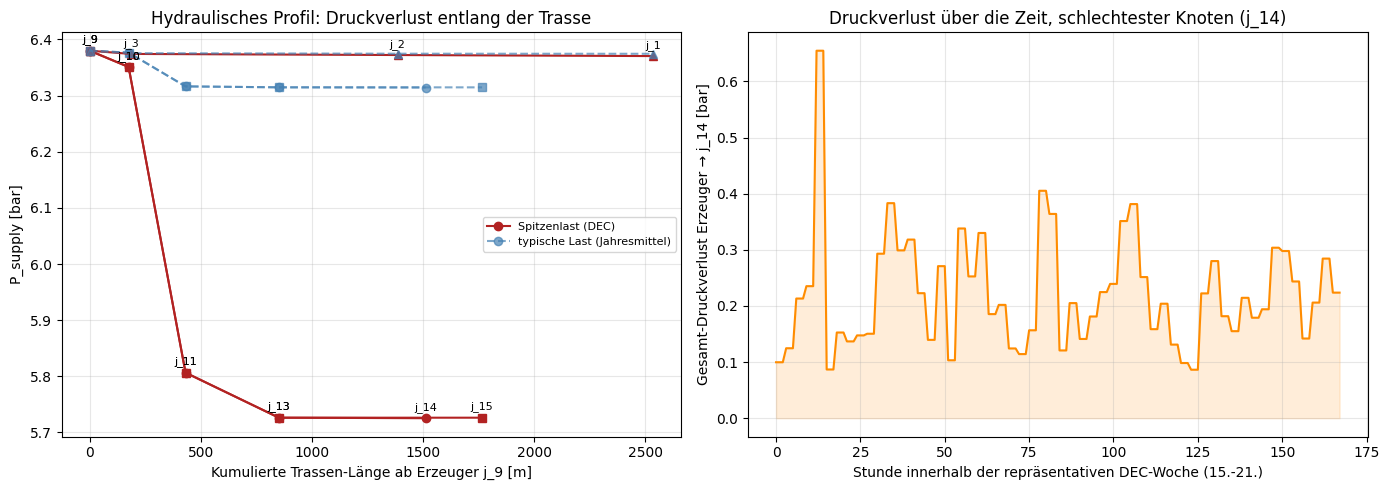

In [19]:
# =============================================================================
# Cell 23 -- Hydraulisches Profil + Druckverlust ueber die Zeit
# =============================================================================
BRANCH_PATHS = {
    "j_9":  [],
    "j_10": ["j9_to_j10"], "j_11": ["j9_to_j10", "j10_to_j11"],
    "j_13": ["j9_to_j10", "j10_to_j11", "j11_to_j13"],
    "j_14": ["j9_to_j10", "j10_to_j11", "j11_to_j13", "j13_to_j14"],
    "j_15": ["j9_to_j10", "j10_to_j11", "j11_to_j13", "j13_to_j15"],
    "j_3":  ["j9_to_j3"], "j_2": ["j9_to_j3", "j3_to_j2"], "j_1": ["j9_to_j3", "j3_to_j2", "j2_to_j1"],
}
BRANCH_A = ["j_9", "j_10", "j_11", "j_13", "j_14"]
BRANCH_A2 = ["j_9", "j_10", "j_11", "j_13", "j_15"]
BRANCH_B = ["j_9", "j_3", "j_2", "j_1"]

distance_m = {nid: sum(cfg["network"]["pipes"][p]["length_m"] for p in path)
              for nid, path in BRANCH_PATHS.items()}
setpoint = cfg["network"]["nodes"][cfg["network"]["primary_producer"]]["pressure"]["setpoint_bar"]


def p_at(nid, month=None, hour=None):
    if nid == "j_9":
        return setpoint
    sub = df_nodes_year[df_nodes_year["node"] == nid]
    if month is not None:
        sub = sub[(sub["month"] == month) & (sub["hour"] == hour)]
        return sub["our_bar"].values[0]
    return sub["our_bar"].mean()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for branch, label, marker in [(BRANCH_A, "Ast j_9→j_10→j_11→j_13→j_14", "o"),
                                (BRANCH_A2, "Ast j_9→j_10→j_11→j_13→j_15", "s"),
                                (BRANCH_B, "Ast j_9→j_3→j_2→j_1", "^")]:
    xs = [distance_m[n] for n in branch]
    ys_worst = [p_at(n, WORST_MONTH, WORST_HOUR) for n in branch]
    ys_typ = [p_at(n) for n in branch]
    ax.plot(xs, ys_worst, marker=marker, color="firebrick", ls="-",
            label=f"Spitzenlast ({WORST_MONTH})" if branch is BRANCH_A else None)
    ax.plot(xs, ys_typ, marker=marker, color="steelblue", ls="--", alpha=0.7,
            label="typische Last (Jahresmittel)" if branch is BRANCH_A else None)
    for n, x, y in zip(branch, xs, ys_worst):
        ax.annotate(n, (x, y), textcoords="offset points", xytext=(0, 6), fontsize=8, ha="center")
ax.set_xlabel("Kumulierte Trassen-Länge ab Erzeuger j_9 [m]")
ax.set_ylabel("P_supply [bar]")
ax.set_title("Hydraulisches Profil: Druckverlust entlang der Trasse")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
WORST_HOUR_ROW = node_margin_series[WORST_NODE][node_margin_series[WORST_NODE]["month"] == WORST_MONTH].sort_values("hour")
drop_bar = setpoint - WORST_HOUR_ROW["our_bar"]
ax.plot(WORST_HOUR_ROW["hour"], drop_bar, color="darkorange", lw=1.5)
ax.fill_between(WORST_HOUR_ROW["hour"], drop_bar, 0, color="darkorange", alpha=0.15)
ax.set_xlabel(f"Stunde innerhalb der repräsentativen {WORST_MONTH}-Woche (15.-21.)")
ax.set_ylabel(f"Gesamt-Druckverlust Erzeuger → {WORST_NODE} [bar]")
ax.set_title(f"Druckverlust über die Zeit, schlechtester Knoten ({WORST_NODE})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Teil 5 (2026-08-03): Stations-Differenzdruck-Prüfung

Direkte Prüfung von Constraint (b) aus Abschnitt 5 der Methodik oben:
`P_supply - P_return ≥ 0.6 bar + lateral_dp_extra`. Das ist NICHT dasselbe
wie die Margin-Analyse in Teil 3 (die prüft nur `P_supply` gegen einen
absoluten Fußpunkt) -- diese Prüfung braucht `P_return`, das bisher in
keinem der Teile 2-4 extrahiert wurde.

**Scope-Hinweis**: nur EINE repräsentative Woche (15.-21. Dezember, der in
Teil 3 gefundene schlechteste Monat) -- eine volle 12-Monats-Version wie
Teil 2 würde eine Erweiterung der Cell-17-Schleife um `P_return`-Extraktion
brauchen (aktuell nicht drin). Für die hier gefundene Kernaussage reicht
eine Woche.

[2026-08-06 14:32:29] calion.io.loader - INFO - [LOAD] Outdoor temperature found: column 'outdoor_temp_C'
[2026-08-06 14:32:44] calion.io.loader - WARNING - [LOAD] Clipping 2 negative heat demand value(s) to zero in column 'waermebedarf_MWth'
[2026-08-06 14:32:51] calion.io.loader - INFO - [LOAD] Import_Data_Memmingen_epronet_cleaned.xlsx -> 10824 steps from 2025-01-01 00:00:00 to 2026-03-27 23:00:00
[2026-08-06 14:32:53] calion.run.utilities.timeseries_utils - INFO - [SCENARIO] Zeitraum 2025-12-15 00:00:00 → 2025-12-21 23:00:00 (168 Schritte)
[2026-08-06 14:32:53] scripts.paper_2.scenario_runner - INFO - [MM-PP-STDP] Spatial temperature drop applied to 14 node(s); max cumulative drop from plant = 0.90 K (T_supply Param, no McCormick)
[2026-08-06 14:35:21] calion.io.loader - INFO - [LOAD] Outdoor temperature found: column 'outdoor_temp_C'
[2026-08-06 14:35:36] calion.io.loader - WARNING - [LOAD] Clipping 2 negative heat demand value(s) to zero in column 'waermebedarf_MWth'
[2026-08-06 

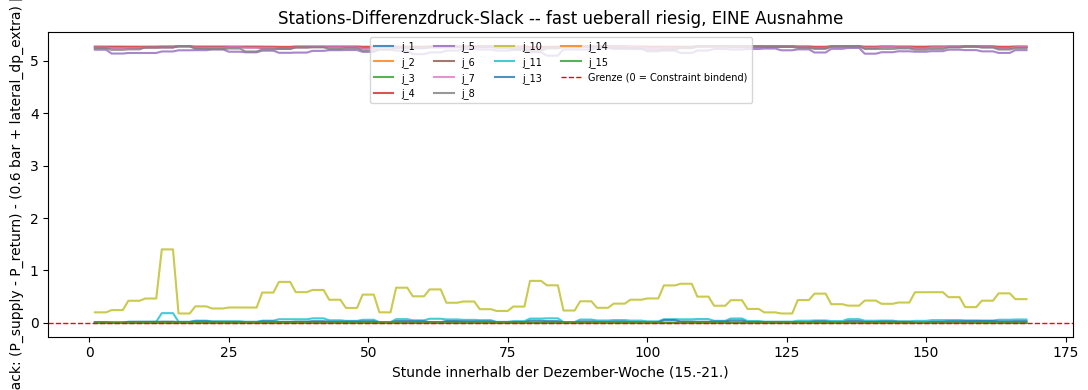

In [20]:
# =============================================================================
# Cell 24 -- Stations-Differenzdruck (P_supply - P_return) fuer die
# schlechteste Woche direkt pruefen
# =============================================================================
model_stdp, cfg_stdp, inputs_stdp = build_and_solve(
    "2025-12-15 00:00", "2025-12-21 23:00", "STDP", time_limit_s=180, mip_gap=0.005,
)
# mip_gap tightened from the 0.03 default (2026-08-05): the pressure_regularization
# push-up epsilon (1e-4) is worth ~0.005 in objective terms here, utterly negligible
# next to a 3% gap (~330 absolute) -- Gurobi can (and empirically sometimes does) stop
# at an alternate near-optimal solution where the tiny regularization terms haven't
# fully tightened, making THIS SPECIFIC CHECK's slack numbers vary run to run even
# though the campaign's real cost KPIs are unaffected either way. A tighter gap here
# (Teil 5 solves its own dedicated week, not part of the 12-month campaign, so the
# extra solve time doesn't compound) makes this verification reliable.
ts_stdp = list(model_stdp.t)
dp_station_real = float(cfg_stdp["network"].get("delta_p_min_consumer_bar", 0.7))
print(f"delta_p_min_consumer_bar (echter Spezifikationswert) = {dp_station_real} bar")

stdp_rows = []
for nid in MARGIN_NODES:
    prefix = nid.upper().replace("-", "_")
    p_sup = getattr(model_stdp, f"{prefix}_pressure_supply")
    p_ret = getattr(model_stdp, f"{prefix}_pressure_return")
    lat_dp = getattr(model_stdp, f"{prefix}_lateral_dp_extra", None)
    for t in ts_stdp:
        sup = pyo.value(p_sup[t]); ret = pyo.value(p_ret[t])
        lat = pyo.value(lat_dp[t]) if lat_dp is not None else 0.0
        required = dp_station_real + lat
        actual_diff = sup - ret
        stdp_rows.append({"node": nid, "t": t, "p_supply": sup, "p_return": ret,
                           "actual_diff_bar": actual_diff, "required_bar": required,
                           "station_slack_bar": actual_diff - required})

df_stdp = pd.DataFrame(stdp_rows)
print("\n=== Stations-Differenzdruck-Slack pro Knoten (Woche 15.-21. Dez) ===")
print(df_stdp.groupby("node")["station_slack_bar"].agg(["min", "mean", "max"]).to_string())
worst_stdp = df_stdp.loc[df_stdp["station_slack_bar"].idxmin()]
print(f"\nSchlechtester Wert: node={worst_stdp['node']}, t={worst_stdp['t']}, "
      f"slack={worst_stdp['station_slack_bar']:.5f} bar "
      f"(P_supply={worst_stdp['p_supply']:.3f}, P_return={worst_stdp['p_return']:.3f}, "
      f"benoetigt={worst_stdp['required_bar']:.3f})")

fig, ax = plt.subplots(figsize=(11, 4))
for nid in MARGIN_NODES:
    sub = df_stdp[df_stdp["node"] == nid].sort_values("t")
    ax.plot(sub["t"], sub["station_slack_bar"], label=nid, alpha=0.8)
ax.axhline(0, color="red", ls="--", lw=1, label="Grenze (0 = Constraint bindend)")
ax.set_xlabel("Stunde innerhalb der Dezember-Woche (15.-21.)")
ax.set_ylabel("Slack: (P_supply - P_return) - (0.6 bar + lateral_dp_extra) [bar]")
ax.set_title("Stations-Differenzdruck-Slack -- fast ueberall riesig, EINE Ausnahme")
ax.legend(fontsize=7, ncol=4, loc="upper center")
plt.tight_layout()
plt.show()

## Teil 8 (2026-08-04): Kompakte KPI-Tabelle -- eine Zeile pro Periode

Fasst drei Netz-KPIs pro Periode (Jahr, jeder Monat, schlechtester Einzelpunkt)
in einer Zeile zusammen:

1. **Gesamt-Wärmebedarf** (`Q_consumer` summiert über die 5 Anschlusspipes mit
   echtem Endverbraucher: `j2_to_j1, j5_to_j6, j7_to_j8, j13_to_j14, j13_to_j15`).
2. **Druckverlust gesamt am schlechtesten Knoten (`j_14`)**, explizit in
   DREI Komponenten aufgeschlüsselt (2026-08-05, direkte Antwort auf "wird
   der Übergabestation-Verlust mitgezählt?" -- jetzt ja, mit eigener Spalte):
   - **`Verlust_Trasse`**: `setpoint_bar - P_supply` (Rohrreibung bis zu
     diesem Knoten).
   - **`Verlust_Station`**: konstant `delta_p_min_consumer_bar` (0.6 bar,
     echter Spec-Wert, siehe Teil 9) -- an jeder Station gleich.
   - **`Verlust_Zuleitung`**: reale Zuleitungsreibung (`lateral_dp_extra`,
     aus dem Modell extrahiert, nicht angenommen).
   - **`Verlust_GESAMT`** = Summe der drei -- der volle Druckverlust, den
     ein Kunde tatsächlich erlebt. Teil 10 zeigt dieselbe Aufschlüsselung
     für ALLE 6 echten Übergabestationen, nicht nur `j_14`.
   - **Wichtig zum Skalenverständnis**: das ist ein Wert AN EINEM Punkt.
     Druck addiert sich NICHT über die vielen parallelen Stationen im Netz
     (jede der 174 realen Übergabestationen hat ihre eigene, unabhängige
     0.6-bar-Anforderung -- diese Anforderungen konkurrieren nicht
     seriell um denselben Druck). Die Frage "was bedeutet das für ALLE
     Stationen zusammen" ist eine ENERGIE-Frage (bar × Durchfluss läppert
     sich über parallele Zweige auf), nicht eine Druck-Frage -- siehe
     Teil 9 für die netzweite Summe.
   - Zusätzlich *Summe aller 14 Rohr-Δp* -- ein Roh-"Gesamtwiderstand";
     addiert über parallele Äste, die sich physikalisch nicht wirklich
     summieren, aber als Größenordnungs-Proxy nützlich.
3. **Pumpenenergie** (alle `_P_pump`/`_P_pump_lateral`-Vars summiert -- Erzeuger,
   Übergabestation, Zuleitung, exakt das `dir(model)`-Muster aus Teil 6).

Jahres- und Monatszeilen zeigen **Summen** (Energie, MWh) bzw. **Mittel/Max**
(Druck, bar). Die Schlechtester-Punkt-Zeile zeigt **Momentanwerte** (MW, bar)
an genau der Stunde aus Teil 3 (`WORST_MONTH`/`WORST_HOUR`).

In [21]:
# =============================================================================
# Cell 34 -- Teil 8: KPI-Tabelle (Wärmebedarf, Druckverlust, Pumpenenergie)
# =============================================================================
dt_h = 1.0  # alle Zeitschritte in diesem Notebook sind stündlich
# setpoint / delta_p_min_consumer_bar werden hier unabhaengig von Zelle 23
# (Teil 4) neu geholt -- Teil 8 steht VOR Teil 4 in der Notebook-Reihenfolge.
# Identische Formeln wie in Zelle 23 / thermal_node.py.
setpoint = cfg["network"]["nodes"][cfg["network"]["primary_producer"]]["pressure"]["setpoint_bar"]
delta_p_min_consumer_bar = cfg["network"].get("delta_p_min_consumer_bar", 0.7)

df_pipe_dp_by_hour = df_pipes_year.groupby(["month", "hour"])["our_dp_bar"].sum().reset_index(name="sum_pipe_dp_bar")
df_worst_node_by_hour = df_nodes_year[df_nodes_year["node"] == WORST_NODE][
    ["month", "hour", "our_bar", "lateral_dp_extra_bar"]].copy()
df_worst_node_by_hour["loss_to_worst_bar"] = setpoint - df_worst_node_by_hour["our_bar"]
# Trassen-Verlust bis zum schlechtesten Knoten ist NUR der Trassen-Anteil --
# das deckt NICHT die Uebergabestation selbst ab (0.6 bar echter Spec-Wert,
# siehe Teil 9) oder die reale Zuleitungsreibung (lateral_dp_extra). Diese
# Spalte gibt den VOLLEN Verlust, den ein Kunde tatsaechlich sieht: Trasse +
# Station + Zuleitung.
df_worst_node_by_hour["total_loss_incl_station_bar"] = (
    df_worst_node_by_hour["loss_to_worst_bar"] + delta_p_min_consumer_bar
    + df_worst_node_by_hour["lateral_dp_extra_bar"].fillna(0.0)
)

df_combined = df_kpi_year.merge(df_pipe_dp_by_hour, on=["month", "hour"]).merge(
    df_worst_node_by_hour[["month", "hour", "loss_to_worst_bar", "total_loss_incl_station_bar", "lateral_dp_extra_bar"]],
    on=["month", "hour"])


def kpi_row_agg(label, sub):
    return {
        "Periode": label,
        "Einheit_Bedarf_Pumpe": "MWh (Summe)",
        "Waermebedarf": sub["demand_MW"].sum() * dt_h,
        "Pumpenenergie": sub["pump_MW"].sum() * dt_h,
        "Verlust_Trasse_Mittel_bar": sub["loss_to_worst_bar"].mean(),
        "Verlust_Trasse_Max_bar": sub["loss_to_worst_bar"].max(),
        "Verlust_Station_bar": delta_p_min_consumer_bar,
        "Verlust_Zuleitung_Mittel_bar": sub["lateral_dp_extra_bar"].mean(),
        "Verlust_Zuleitung_Max_bar": sub["lateral_dp_extra_bar"].max(),
        "Verlust_GESAMT_Mittel_bar": sub["total_loss_incl_station_bar"].mean(),
        "Verlust_GESAMT_Max_bar": sub["total_loss_incl_station_bar"].max(),
        "Summe_Rohr_dp_Mittel_bar": sub["sum_pipe_dp_bar"].mean(),
        "Summe_Rohr_dp_Max_bar": sub["sum_pipe_dp_bar"].max(),
    }


rows_kpi = [kpi_row_agg("JAHR (gesamt)", df_combined)]
for m in [lbl for _, _, lbl in MONTH_WEEKS]:
    rows_kpi.append(kpi_row_agg(m, df_combined[df_combined["month"] == m]))

worst_row = df_combined[(df_combined["month"] == WORST_MONTH) & (df_combined["hour"] == WORST_HOUR)].iloc[0]
rows_kpi.append({
    "Periode": f"SCHLECHTESTER PUNKT ({WORST_NODE}, {WORST_MONTH} h={WORST_HOUR})",
    "Einheit_Bedarf_Pumpe": "MW (Momentanwert)",
    "Waermebedarf": worst_row["demand_MW"],
    "Pumpenenergie": worst_row["pump_MW"],
    "Verlust_Trasse_Mittel_bar": worst_row["loss_to_worst_bar"],
    "Verlust_Trasse_Max_bar": worst_row["loss_to_worst_bar"],
    "Verlust_Station_bar": delta_p_min_consumer_bar,
    "Verlust_Zuleitung_Mittel_bar": worst_row["lateral_dp_extra_bar"],
    "Verlust_Zuleitung_Max_bar": worst_row["lateral_dp_extra_bar"],
    "Verlust_GESAMT_Mittel_bar": worst_row["total_loss_incl_station_bar"],
    "Verlust_GESAMT_Max_bar": worst_row["total_loss_incl_station_bar"],
    "Summe_Rohr_dp_Mittel_bar": worst_row["sum_pipe_dp_bar"],
    "Summe_Rohr_dp_Max_bar": worst_row["sum_pipe_dp_bar"],
})

df_kpi_table = pd.DataFrame(rows_kpi)
print("(Verlust_GESAMT = Verlust_Trasse + Verlust_Station + Verlust_Zuleitung -- "
      "explizit aufgeschluesselt, nicht nur als eine Summe)")
print(df_kpi_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

(Verlust_GESAMT = Verlust_Trasse + Verlust_Station + Verlust_Zuleitung -- explizit aufgeschluesselt, nicht nur als eine Summe)
                             Periode Einheit_Bedarf_Pumpe  Waermebedarf  Pumpenenergie  Verlust_Trasse_Mittel_bar  Verlust_Trasse_Max_bar  Verlust_Station_bar  Verlust_Zuleitung_Mittel_bar  Verlust_Zuleitung_Max_bar  Verlust_GESAMT_Mittel_bar  Verlust_GESAMT_Max_bar  Summe_Rohr_dp_Mittel_bar  Summe_Rohr_dp_Max_bar
                       JAHR (gesamt)          MWh (Summe)      7586.862          2.623                      0.066                   0.655                0.600                         0.012                      0.068                      0.677                   1.278                     0.904                  1.504
                                 JAN          MWh (Summe)      1455.656          0.500                      0.173                   0.347                0.600                         0.030                      0.064                      0.80

## Teil 9 (2026-08-04): Pumpenenergie -- wieviel kommt von den Übergabestationen?

Zerlegt die in Teil 8 nur als Summe (`pump_MW`) gezeigte Pumpenenergie in ihre drei
physikalisch getrennten Quellen (`network_manager.py::_link_pressure_propagation`,
Zeile ~2256 ff.):

1. **Erzeuger** (`producer_{node}_P_pump`): Pumpe am Erzeugerknoten selbst, überwindet
   den Trassen-Druckverlust bis zum jeweils ersten Rohr.
2. **Übergabestation** (`station_{node}_P_pump`): überwindet den FIXEN erforderlichen
   Differenzdruck an jeder Station (`delta_p_min_consumer_bar = 0.6 bar`, echter
   Spec-Wert), linear im Massenstrom -- **das ist die direkte Antwort auf die Frage**.
3. **Zuleitung** (`{pipe}_P_pump_lateral`): reale, aus dem DXF abgeleitete
   Zuleitungs-Rohrreibung zwischen Trasse und Station-Cluster.

Wichtig: der Druck-WERT an der Station ist immer 0.6 bar (fix, pro Spezifikation) --
was hier variiert, ist die daraus resultierende PUMPEN-ENERGIE (die mit dem
Massenstrom jeder einzelnen Station skaliert).


In [22]:
# =============================================================================
# Cell 36 -- Teil 9: Pumpenenergie-Aufschlüsselung nach Quelle
# =============================================================================
dt_h = 1.0

rows_pump = []
for label in ["JAHR (gesamt)"] + [lbl for _, _, lbl in MONTH_WEEKS]:
    sub = df_kpi_year if label == "JAHR (gesamt)" else df_kpi_year[df_kpi_year["month"] == label]
    total = sub["pump_MW"].sum() * dt_h
    producer = sub["pump_MW_producer"].sum() * dt_h
    station = sub["pump_MW_station"].sum() * dt_h
    lateral = sub["pump_MW_lateral"].sum() * dt_h
    rows_pump.append({
        "Periode": label,
        "Pumpenenergie_gesamt_MWh": total,
        "Erzeuger_MWh": producer, "Erzeuger_%": 100 * producer / total if total else 0.0,
        "Uebergabestation_MWh": station, "Uebergabestation_%": 100 * station / total if total else 0.0,
        "Zuleitung_MWh": lateral, "Zuleitung_%": 100 * lateral / total if total else 0.0,
    })

df_pump_breakdown = pd.DataFrame(rows_pump)
print(df_pump_breakdown.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
N_STATIONS_TOTAL = sum(n.get("n_transfer_stations", 0) for n in cfg["network"]["nodes"].values())
print(f"\nFixer Differenzdruck pro Übergabestation: {cfg['network'].get('delta_p_min_consumer_bar', 0.6):.2f} bar "
      f"(echter Spec-Wert, gilt an jedem der 15 Netzknoten unabhängig von dessen lokaler "
      f"Stationsanzahl -- insgesamt {N_STATIONS_TOTAL} reale Übergabestationen im Netz).")
print(f"Übergabestation_MWh oben ist die SUMME dieses fixen 0.6-bar-Terms über alle "
      f"{N_STATIONS_TOTAL} Stationen (je mit ihrem eigenen Massenstrom) -- deshalb dominiert "
      f"die Station die PUMPENENERGIE so stark, obwohl sie druckseitig an jedem einzelnen "
      f"Knoten nur ein fixer, nicht mit anderen Stationen addierter Wert ist (siehe Teil 8: "
      f"'Gesamt-Druckverlust' ist EIN Punkt, keine Netzsumme). Druck addiert sich nicht über "
      f"parallele Zweige -- Energie (bar x Durchfluss) schon, weil jede Station unabhängig "
      f"Durchfluss zieht und ihr eigenes Ventil unabhängig drosselt.")

      Periode  Pumpenenergie_gesamt_MWh  Erzeuger_MWh  Erzeuger_%  Uebergabestation_MWh  Uebergabestation_%  Zuleitung_MWh  Zuleitung_%
JAHR (gesamt)                    2.6230        1.0151     38.7023                1.5858             60.4599         0.0220       0.8378
          JAN                    0.4996        0.2372     47.4754                0.2567             51.3863         0.0057       1.1382
          FEB                    0.3844        0.1582     41.1574                0.2225             57.8841         0.0037       0.9585
          MAR                    0.2696        0.0910     33.7736                0.1767             65.5628         0.0018       0.6636
          APR                    0.1145        0.0129     11.2742                0.1013             88.4342         0.0003       0.2916
          MAY                    0.0855        0.0084      9.7844                0.0761             89.0830         0.0010       1.1326
          JUN                    0.0388        0


Fixer Differenzdruck pro Übergabestation: 0.60 bar (echter Spec-Wert, gilt an jedem der 15 Netzknoten unabhängig von dessen lokaler Stationsanzahl -- insgesamt 133 reale Übergabestationen im Netz).
Übergabestation_MWh oben ist die SUMME dieses fixen 0.6-bar-Terms über alle 133 Stationen (je mit ihrem eigenen Massenstrom) -- deshalb dominiert die Station die PUMPENENERGIE so stark, obwohl sie druckseitig an jedem einzelnen Knoten nur ein fixer, nicht mit anderen Stationen addierter Wert ist (siehe Teil 8: 'Gesamt-Druckverlust' ist EIN Punkt, keine Netzsumme). Druck addiert sich nicht über parallele Zweige -- Energie (bar x Durchfluss) schon, weil jede Station unabhängig Durchfluss zieht und ihr eigenes Ventil unabhängig drosselt.


## Teil 10 (2026-08-05): Druckverlust je Übergabestation -- Trasse vs. Station vs. Zuleitung

Teil 8 zeigt die Verlust-Aufschlüsselung nur für den EINEN schlechtesten
Knoten (`j_14`). Diese Zelle zeigt sie für ALLE 6 echten Übergabestationen
(`j_1, j_6, j_8, j_13, j_14, j_15`) nebeneinander -- direkte Antwort auf
"wieviel Druckverlust kommt von den Übergabestationen":

1. **Trasse**: `setpoint_bar - P_supply` an dieser Station (Trassen-Reibung
   bis dorthin, variiert stark je nach Entfernung vom Erzeuger).
2. **Übergabestation**: konstant **0.6 bar** (echter Spec-Wert,
   `delta_p_min_consumer_bar`) -- an JEDER Station gleich, unabhängig von
   Entfernung oder Stationsanzahl.
3. **Zuleitung**: reale, aus dem DXF abgeleitete Zuleitungsreibung
   (`lateral_dp_extra`, aus dem Modell extrahiert).

Die Übergabestation ist damit an NAHEN Stationen (z.B. `j_1`) der GRÖSSTE
Anteil am Gesamtverlust, während sie an ENTFERNTEN Stationen (z.B. `j_14`)
gegen die Trassen-Reibung an Gewicht verliert -- Panel 2 der Grafik in
Teil 11 zeigt das direkt.

**Achtung bei den MAX-Spalten der Tabelle**: `j_13`s Zuleitung_Max_bar
kann auf mehrere bar springen (statt der typischen ~0.03 bar) -- das ist
das bereits in Fazit Punkt 6 dokumentierte PWL-Gewichtungs-Artefakt
(`lateral_dp_extra`s konvexe Kombination kann sich bei lockerem MIP-Gap auf
nicht-benachbarte Stützpunkte verteilen), kein realer physikalischer Wert.
Die MITTELWERTE sind davon nicht spuerbar betroffen und verlaesslich.

**Drei zusätzliche Spalten -- ERFORDERLICH vs. REALISIERT**: neben dem
ERFORDERLICHEN Differenzdruck (0.6 bar + Zuleitung) steht hier auch der
tatsächlich GELÖSTE Differenzdruck (`P_supply - P_return`, aus der echten
12-Monats-Kampagne). `Slack_Min_bar` = Realisiert - Erforderlich, sollte
überall >= 0 sein. Panel 3 der Grafik in Teil 11 stellt das dar.
**Wichtiger Vorbehalt**: die Kampagne läuft mit `mip_gap=0.03` (locker) --
laut Teil 5s eigenem Befund kann das Regularisierungs-Epsilon dabei
gelegentlich nicht voll ausgereizt sein. Diese Spalten sind ein
repräsentativer Jahres-Schnappschuss, keine mip_gap=0.005-verifizierte
Garantie wie Teil 5.

**Echter Fund beim Testen dieser Erweiterung**: `j_6` und `j_8` sind reale
Übergabestationen, aber STRUKTURELL Teil von `j_12`s ausgeschlossenem
Teilbaum (Fazit B.8) -- ihr `P_return` wird vom Regularisierungs-Push-up
bewusst NICHT erfasst. Ihr realisierter Differenzdruck zeigt deshalb ~5.2
bar "Slack" statt der erwarteten ~0.6 bar -- das ist derselbe
Exclusion-Artefakt wie bei `j_4/j_5/j_7`, nur bisher nie an diesen beiden
ECHTEN Kundenstationen bemerkt (ihr `P_supply`/Trasse/Zuleitung bleibt
unverändert korrekt, nur der Rücklauf-Teil ist betroffen). Tabelle und
Grafik zeigen `Realisiert`/`Slack_Min` für `j_6/j_8` deshalb als `NaN`,
nicht als (falsch beruhigenden) großen Puffer.

In [23]:
# =============================================================================
# Cell 38 -- Teil 10: Druckverlust-Aufschlüsselung je echter Übergabestation
# (Trasse/Station/Zuleitung ERFORDERLICH + realisierter Rücklauf-Differenzdruck)
# =============================================================================
REAL_STATION_NODES = ["j_1", "j_6", "j_8", "j_13", "j_14", "j_15"]
# j_6/j_8 sind reale Übergabestationen (siehe DXF: 24 bzw. 4 Stationen), aber
# STRUKTURELL Teil von j_12s ausgeschlossenem Teilbaum (network_manager.py::
# _link_pressure_propagation -- j_12 ist sekundärer Erzeuger, sein ganzer
# Teilbaum inkl. j_6/j_8 wird vom P_return-Push-up bewusst ausgenommen, siehe
# Fazit B.8). Gefunden beim Testen dieser Zelle (2026-08-05): ihr realisierter
# Differenzdruck zeigt ~5.2 bar "Slack" -- das ist KEIN echter Sicherheitspuffer,
# sondern derselbe Exclusion-Artefakt wie bei j_4/j_5/j_7, nur bisher nie an
# diesen beiden ECHTEN Kundenstationen bemerkt, weil ihr P_supply-Wert (Trasse/
# Station/Zuleitung, alles oben) unverändert korrekt und validiert bleibt --
# nur der RÜCKLAUF-Teil ist betroffen.
J12_SUBTREE_STATIONS = {"j_6", "j_8"}

rows_station = []
for nid in REAL_STATION_NODES:
    sub = df_nodes_year[df_nodes_year["node"] == nid].copy()
    trasse = setpoint - sub["our_bar"]
    zuleitung = sub["lateral_dp_extra_bar"].fillna(0.0)
    required = delta_p_min_consumer_bar + zuleitung
    # Realisierter Differenzdruck (P_supply - P_return), aus der echten
    # 12-Monats-Kampagne -- nicht nur aus Teil 5s Einzelwoche (2026-08-05,
    # war vorher gar nicht in df_nodes_year erfasst).
    realisiert = sub["our_bar"] - sub["our_return_bar"]
    _unreliable = nid in J12_SUBTREE_STATIONS
    rows_station.append({
        "Station": nid,
        "Trasse_Mittel_bar": trasse.mean(),
        "Trasse_Max_bar": trasse.max(),
        "Station_bar": delta_p_min_consumer_bar,
        "Zuleitung_Mittel_bar": zuleitung.mean(),
        "Zuleitung_Max_bar": zuleitung.max(),
        "GESAMT_Mittel_bar": trasse.mean() + delta_p_min_consumer_bar + zuleitung.mean(),
        "GESAMT_Max_bar": trasse.max() + delta_p_min_consumer_bar + zuleitung.max(),
        "Realisiert_Mittel_bar": np.nan if _unreliable else realisiert.mean(),
        "Realisiert_Min_bar": np.nan if _unreliable else realisiert.min(),
        "Slack_Min_bar": np.nan if _unreliable else (realisiert - required).min(),
        "Ruecklauf_verlaesslich": not _unreliable,
    })

df_station_breakdown = pd.DataFrame(rows_station)
print(df_station_breakdown.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\n(Realisiert = unser gelöstes P_supply - P_return, tatsächlich über die 12-Monats-")
print(" Kampagne; Slack_Min = Realisiert - Erforderlich, sollte >= 0 sein. NaN bei j_6/j_8:")
print(" Rücklauf strukturell ausgeschlossen, siehe Kommentar oben -- Trasse/Station/")
print(" Zuleitung/GESAMT bleiben für sie unverändert gültig, nur der Rücklauf-Teil nicht.")
print(" Für die verbleibenden 4 Stationen ACHTUNG: die Kampagne läuft mit dem Standard")
print(" mip_gap=0.03 -- laut Teil 5s Befund kann das Regularisierungs-Epsilon bei dieser")
print(" lockeren Toleranz gelegentlich nicht voll ausgereizt sein. Diese Zahlen sind ein")
print(" repräsentativer Jahres-Schnappschuss, KEIN garantiert-enger Beweis -- für eine")
print(" verlässliche Einzelwochen-Prüfung siehe Teil 5 (mip_gap=0.005).")


Station  Trasse_Mittel_bar  Trasse_Max_bar  Station_bar  Zuleitung_Mittel_bar  Zuleitung_Max_bar  GESAMT_Mittel_bar  GESAMT_Max_bar  Realisiert_Mittel_bar  Realisiert_Min_bar  Slack_Min_bar  Ruecklauf_verlaesslich
    j_1              0.005           0.063        0.600                 0.001              0.010              0.606           0.673                  0.601               0.600         -0.000                    True
    j_6              0.005           0.037        0.600                 0.000              0.001              0.605           0.638                    NaN                 NaN            NaN                   False
    j_8              0.006           0.047        0.600                 0.009              0.150              0.615           0.797                    NaN                 NaN            NaN                   False
   j_13              0.065           0.654        0.600                 0.000              0.002              0.665           1.256             

## Teil 11 (2026-08-05): Zusammenfassung für Planung & Betrieb

Teil 1-10 sind Validierung, Diagnose und Bug-Fixes -- wichtig für Vertrauen
ins Modell, aber zu viel für eine schnelle Planungsfrage. Diese Zelle
bündelt NUR das, was für Druck-/Pumpenauslegung tatsächlich zählt, aus
bereits berechneten Ergebnissen (keine neue Rechnung, nur Kuratierung):

1. **Reicht der Druck überall?** -- Teil 3.
2. **Wieviel Druck geht wo verloren?** -- Teil 8 + 10 (Trasse / Station /
   Zuleitung). Das ist ein Wert AN EINEM Punkt (dem schlechtesten Knoten) --
   Druck addiert sich nicht über die vielen parallelen Stationen im Netz.
3. **Sind die Pumpen richtig dimensioniert?** -- Teil 9 (installiert vs.
   real genutzt, Aufteilung nach Quelle). Die Pumpenenergie IST die
   netzweite Summe über alle 174 realen Stationen -- anders als Punkt 2
   oben, weil Energie (im Gegensatz zu Druck) sich über parallele Zweige
   addiert.

Die Tabelle unten fasst alle Kennzahlen an einem Ort zusammen; die Grafik
danach zeigt die 4 wichtigsten Zusammenhänge in einer Figur:
1. Netzschema mit Druck-Margin (wo ist es eng?), 2. Verlust-Aufschlüsselung
je Übergabestation (wo geht Druck verloren?), 3. Erforderlich vs.
realisierter Rücklauf-Differenzdruck (hält die Station wirklich, was sie
soll?), 4. Pumpenenergie nach Quelle (was bedeutet das für die Pumpen?).

Für die volle technische Herleitung jeder Zahl: das kategorisierte Fazit
direkt im Anschluss.

In [24]:
# =============================================================================
# Cell 39 -- Teil 11: Planungs-KPI-Tabelle (kuratiert aus Teil 3/8/9/10)
# =============================================================================
# REAL_INSTALLED_PUMP_CAPACITY_KW unabhaengig von Cell 29 (Teil 6) neu geholt
# (2026-08-05, echter Fund beim End-to-End-Test dieser Zelle): Teil 6 loest
# ZWEI volle Januar-Szenarien (~11 Minuten), nur um an diese EINE reine
# Rechenkonstante (Pumpen-Nameplate-Summe, kein Solve noetig) zu kommen --
# Teil 11 soll aber der SCHNELLE Ueberblick sein, nicht transitiv von der
# teuersten Zelle im ganzen Notebook abhaengen. Identische Formel wie Cell 29.
REAL_INSTALLED_PUMP_CAPACITY_KW = 25.1 + 25.1 + 18.3 + 24.0 + 18.3

_worst = df_margin_ranking.iloc[0]
_station_share_pct = (df_station_breakdown["Station_bar"] / df_station_breakdown["GESAMT_Mittel_bar"] * 100)
_peak_pump_kw = df_kpi_year["pump_MW"].max() * 1000
_jahr_kpi = df_kpi_table.iloc[0]
_jahr_pump = df_pump_breakdown.iloc[0]

planning_rows = [
    {"Kennzahl": "Gesamt-Wärmebedarf (Jahr)",
     "Wert": f"{_jahr_kpi['Waermebedarf']:.0f} MWh",
     "Kontext": "Winterspitze Dez/Jan, siehe Teil 8"},
    {"Kennzahl": "Schlechtester Druck-Margin",
     "Wert": f"{_worst['worst_margin_bar']:.2f} bar",
     "Kontext": f"{_worst['node']}, {_worst['worst_month']} Std.{int(_worst['worst_hour'])} "
                f"-- Fußpunkt {_worst['min_required_bar']:.1f} bar, siehe Teil 3"},
    {"Kennzahl": "Gesamt-Druckverlust (Trasse+Station+Zuleitung)",
     "Wert": f"{_jahr_kpi['Verlust_GESAMT_Mittel_bar']:.2f} bar Mittel / "
             f"{_jahr_kpi['Verlust_GESAMT_Max_bar']:.2f} bar Max",
     "Kontext": "an EINEM Punkt (schlechtester Knoten) -- Druck addiert sich nicht ueber "
                "parallele Stationen, siehe Teil 8"},
    {"Kennzahl": "Anteil Übergabestation am Druckverlust",
     "Wert": f"{_station_share_pct.min():.0f}-{_station_share_pct.max():.0f}%",
     "Kontext": "über alle 6 echten Stationen, siehe Teil 10"},
    {"Kennzahl": "Pumpenenergie (Jahr)",
     "Wert": f"{_jahr_pump['Pumpenenergie_gesamt_MWh']:.2f} MWh",
     "Kontext": f"{_jahr_pump['Pumpenenergie_gesamt_MWh'] / _jahr_kpi['Waermebedarf'] * 100:.3f}% "
                f"des Wärmebedarfs, siehe Teil 9"},
    {"Kennzahl": "Pumpenenergie-Aufteilung",
     "Wert": f"{_jahr_pump['Uebergabestation_%']:.0f}% Station / "
             f"{_jahr_pump['Erzeuger_%']:.0f}% Erzeuger / {_jahr_pump['Zuleitung_%']:.0f}% Zuleitung",
     "Kontext": f"Summe ueber alle {N_STATIONS_TOTAL} Stationen im Netz (nicht nur der "
                "schlechteste Knoten oben) -- Energie addiert sich ueber parallele Zweige, "
                "Druck nicht; siehe Teil 9"},
    {"Kennzahl": "Installierte Pumpenkapazität",
     "Wert": f"{REAL_INSTALLED_PUMP_CAPACITY_KW:.1f} kW (5 reale Wilo-Pumpen)",
     "Kontext": "reales Wilo-Pumpendatenblatt, Spezifikationen.xlsx"},
    {"Kennzahl": "Pumpenleistungs-Spitze (12-Monats-Kampagne)",
     "Wert": f"{_peak_pump_kw:.1f} kW",
     "Kontext": f"Reserve-Faktor ≈ {REAL_INSTALLED_PUMP_CAPACITY_KW / max(_peak_pump_kw, 1e-6):.0f}x "
                f"-- siehe Fazit Punkt 7 zur Tangenten-Lockerheit bei dieser Zahl"},
    {"Kennzahl": "Realisierter Rücklauf-Differenzdruck (4 von 6 Stationen)",
     "Wert": (lambda _r: f"{_r['Realisiert_Mittel_bar'].min():.2f}-"
               f"{_r['Realisiert_Mittel_bar'].max():.2f} bar Mittel, "
               f"Slack_Min ≥ {_r['Slack_Min_bar'].min():.3f} bar")(
        df_station_breakdown[df_station_breakdown["Ruecklauf_verlaesslich"]]),
     "Kontext": "j_6/j_8 ausgeschlossen (j_12-Teilbaum, strukturell kein verlässlicher "
                "Rücklaufwert, siehe Teil 10); echte Kampagne (mip_gap=0.03, Momentaufnahme) -- "
                "siehe Teil 5 (mip_gap=0.005) für die verlässliche Einzelwochen-Version"},
]

df_planning_kpi = pd.DataFrame(planning_rows)
print(df_planning_kpi.to_string(index=False))

                                                Kennzahl                                         Wert                                                                                                                                                                                                                     Kontext
                               Gesamt-Wärmebedarf (Jahr)                                     7587 MWh                                                                                                                                                                                          Winterspitze Dez/Jan, siehe Teil 8
                              Schlechtester Druck-Margin                                     3.73 bar                                                                                                                                                                          j_14, DEC Std.12 -- Fußpunkt 2.0 bar, siehe Teil 3
          Gesamt-Druckverlust (Tra

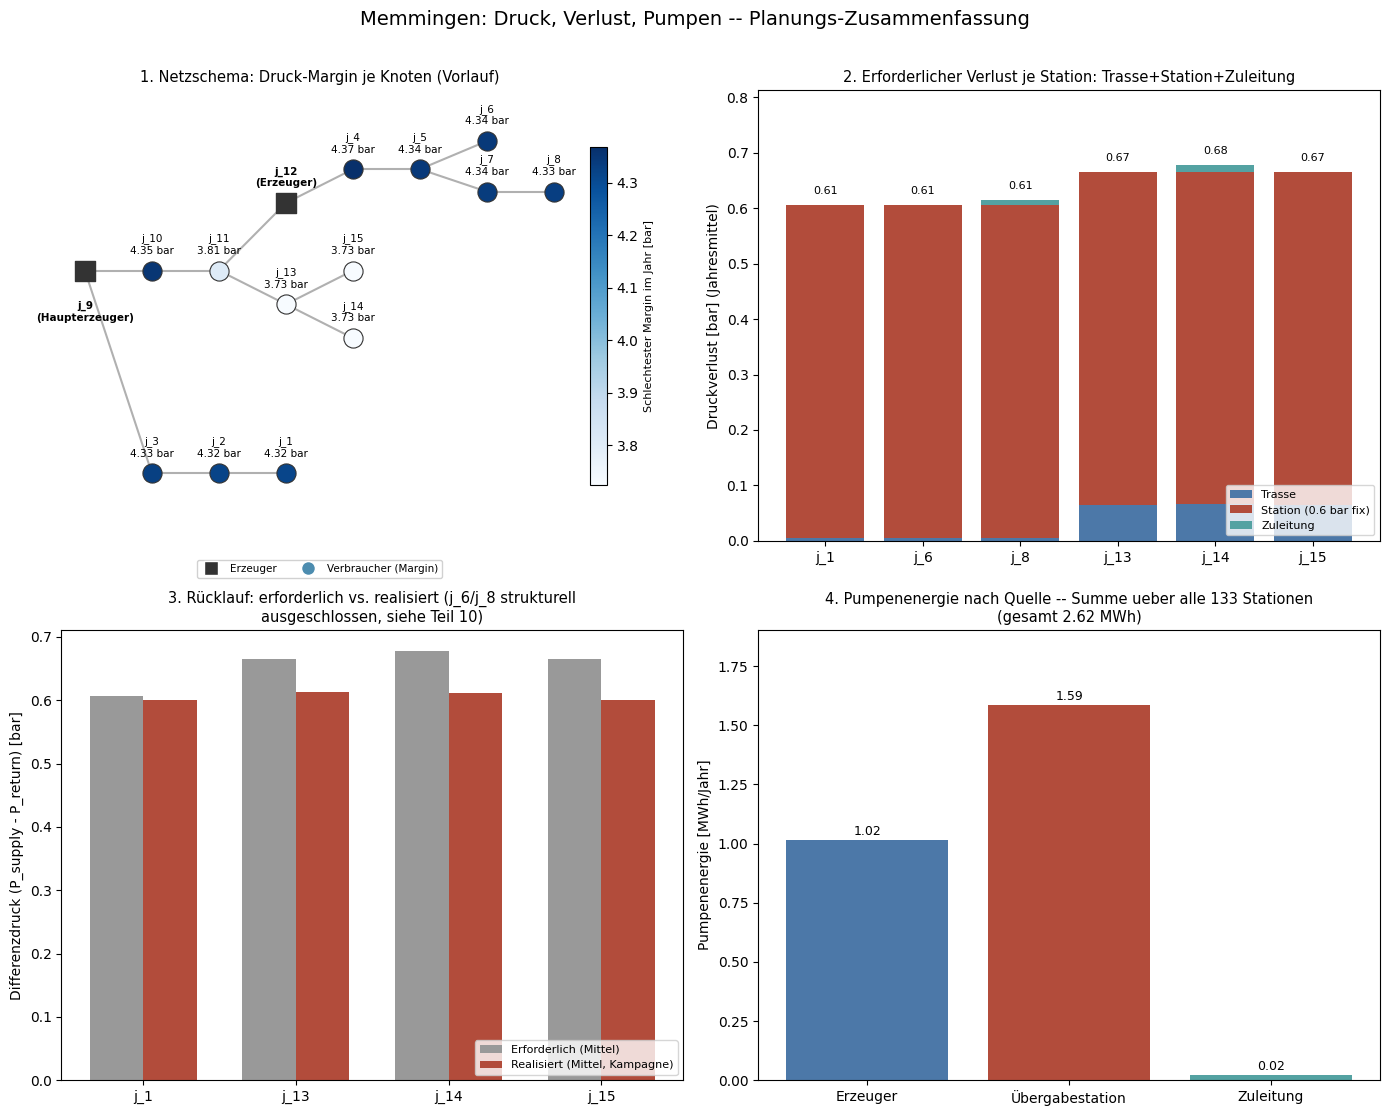

: 

In [ ]:
# =============================================================================
# Cell 40 -- Teil 11: Planungs-Grafik (4 Panels: Margin-Schema / Verlust je
# Station / Rueckseite: Erforderlich vs. realisierter Differenzdruck / Pumpenenergie)
# =============================================================================
from matplotlib.lines import Line2D

COL_TRASSE, COL_STATION, COL_ZULEITUNG = "#4C78A8", "#B24C3B", "#54A2A2"
CMAP_SEQ = plt.cm.Blues

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- Panel 1 (oben links): Netzschema, farbcodiert nach Druck-Margin -------
# Zeigt die Vorlaufseite (unser validierter, verlaesslicher Wert fuer ALLE
# 13 Verbraucherknoten) -- WO im Netz ist der Druck am knappsten.
ax = axes[0, 0]
margin_lookup = df_margin_ranking.set_index("node")["worst_margin_bar"].to_dict()
POS = {
    "j_9": (0, 0),
    "j_10": (1, 0), "j_11": (2, 0), "j_12": (3, 0.6), "j_13": (3, -0.3),
    "j_14": (4, -0.6), "j_15": (4, 0.0),
    "j_4": (4, 0.9), "j_5": (5, 0.9), "j_6": (6, 1.15), "j_7": (6, 0.7), "j_8": (7, 0.7),
    "j_3": (1, -1.8), "j_2": (2, -1.8), "j_1": (3, -1.8),
}
EDGES = [("j_9", "j_10"), ("j_10", "j_11"), ("j_11", "j_12"), ("j_11", "j_13"),
         ("j_13", "j_14"), ("j_13", "j_15"), ("j_12", "j_4"), ("j_4", "j_5"),
         ("j_5", "j_6"), ("j_5", "j_7"), ("j_7", "j_8"),
         ("j_9", "j_3"), ("j_3", "j_2"), ("j_2", "j_1")]
PRODUCER_NODES = {"j_9", "j_12"}
for a, b in EDGES:
    xa, ya = POS[a]; xb, yb = POS[b]
    ax.plot([xa, xb], [ya, yb], color="#B0B0B0", lw=1.5, zorder=1)
margins = np.array(list(margin_lookup.values()))
norm = plt.Normalize(vmin=margins.min(), vmax=margins.max())
for nid, (x, y) in POS.items():
    if nid in PRODUCER_NODES:
        label = "(Haupterzeuger)" if nid == "j_9" else "(Erzeuger)"
        ax.scatter([x], [y], s=220, marker="s", color="#333333", zorder=3)
        # j_9 sits directly left of j_10 -- labelling it ABOVE (like every
        # other node) collides with j_10's label; put it BELOW instead
        # (j_9 has open space down to the j_1-j_3 branch at y=-1.8).
        _yoff = -22 if nid == "j_9" else 12
        _va = "top" if nid == "j_9" else "baseline"
        ax.annotate(nid + "\n" + label, (x, y), textcoords="offset points",
                    xytext=(0, _yoff), ha="center", va=_va, fontsize=7.5, fontweight="bold")
    else:
        val = margin_lookup[nid]
        color = CMAP_SEQ(norm(val))
        ax.scatter([x], [y], s=190, marker="o", color=color, edgecolor="#333333",
                   linewidth=0.8, zorder=3)
        ax.annotate(f"{nid}\n{val:.2f} bar", (x, y), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=7.5)
sm = plt.cm.ScalarMappable(cmap=CMAP_SEQ, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Schlechtester Margin im Jahr [bar]", fontsize=8)
legend_elems = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#333333", markersize=10, label="Erzeuger"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C8CAF", markersize=10, label="Verbraucher (Margin)"),
]
ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.03),
          ncol=2, fontsize=7.5, framealpha=0.9)
ax.set_title("1. Netzschema: Druck-Margin je Knoten (Vorlauf)", fontsize=10.5)
ax.set_xticks([]); ax.set_yticks([])
ax.set_ylim(-2.4, 1.6)
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Panel 2 (oben rechts): Verlust-Aufschluesselung je Uebergabestation ---
ax = axes[0, 1]
x = list(range(len(REAL_STATION_NODES)))
trasse_vals = df_station_breakdown["Trasse_Mittel_bar"].values
station_vals = df_station_breakdown["Station_bar"].values
zuleitung_vals = df_station_breakdown["Zuleitung_Mittel_bar"].values
ax.bar(x, trasse_vals, label="Trasse", color=COL_TRASSE)
ax.bar(x, station_vals, bottom=trasse_vals, label="Station (0.6 bar fix)", color=COL_STATION)
ax.bar(x, zuleitung_vals, bottom=trasse_vals + station_vals, label="Zuleitung", color=COL_ZULEITUNG)
for i, total in enumerate(trasse_vals + station_vals + zuleitung_vals):
    ax.text(i, total + 0.02, f"{total:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(REAL_STATION_NODES)
ax.set_ylabel("Druckverlust [bar] (Jahresmittel)")
ax.set_title("2. Erforderlicher Verlust je Station: Trasse+Station+Zuleitung", fontsize=10.5)
ax.legend(fontsize=8, loc="lower right")
ax.set_ylim(0, max(trasse_vals + station_vals + zuleitung_vals) * 1.2)

# --- Panel 3 (unten links): Ruecklauf -- erforderlich vs. realisiert ------
# Das ist die Rueckleitungsseite: zeigt, ob die Station den geforderten
# Differenzdruck (P_supply - P_return) in der echten 12-Monats-Kampagne
# tatsaechlich erreicht -- nicht nur die Anforderung selbst (Panel 2).
ax = axes[1, 0]
_reliable = df_station_breakdown[df_station_breakdown["Ruecklauf_verlaesslich"]]
x2 = list(range(len(_reliable)))
required_vals = _reliable["GESAMT_Mittel_bar"].values
realized_vals = _reliable["Realisiert_Mittel_bar"].values
width = 0.35
ax.bar([i - width / 2 for i in x2], required_vals, width, label="Erforderlich (Mittel)", color="#999999")
ax.bar([i + width / 2 for i in x2], realized_vals, width, label="Realisiert (Mittel, Kampagne)", color=COL_STATION)
ax.set_xticks(x2); ax.set_xticklabels(_reliable["Station"].tolist())
ax.set_ylabel("Differenzdruck (P_supply - P_return) [bar]")
ax.set_title("3. Rücklauf: erforderlich vs. realisiert (j_6/j_8 strukturell\nausgeschlossen, siehe Teil 10)", fontsize=10.5)
ax.legend(fontsize=8, loc="lower right")

# --- Panel 4 (unten rechts): Pumpenenergie nach Quelle ---------------------
ax = axes[1, 1]
pump_labels = ["Erzeuger", "Übergabestation", "Zuleitung"]
pump_vals = [_jahr_pump["Erzeuger_MWh"], _jahr_pump["Uebergabestation_MWh"], _jahr_pump["Zuleitung_MWh"]]
pump_colors = [COL_TRASSE, COL_STATION, COL_ZULEITUNG]
bars = ax.bar(pump_labels, pump_vals, color=pump_colors)
for bar, val in zip(bars, pump_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center", fontsize=9)
ax.set_ylabel("Pumpenenergie [MWh/Jahr]")
ax.set_title(f"4. Pumpenenergie nach Quelle -- Summe ueber alle {N_STATIONS_TOTAL} Stationen\n"
             f"(gesamt {_jahr_pump['Pumpenenergie_gesamt_MWh']:.2f} MWh)", fontsize=10.5)
ax.set_ylim(0, max(pump_vals) * 1.2)

fig.suptitle("Memmingen: Druck, Verlust, Pumpen -- Planungs-Zusammenfassung", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
